## imports

In [1]:
import re

import pandas as pd
from IPython.display import display
from pathlib import Path
import os
from datetime import datetime, timedelta
import numpy as np
import urllib3
from bs4 import BeautifulSoup
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import requests
import sys
import traceback

# Caminho da pasta "root"
base_dir = Path(os.getcwd()).resolve().parent  # Ajustar se necessário
data_dir = base_dir / "data"
base_dir

WindowsPath('C:/Users/diogo/Desktop/EuroMillions')

In [2]:
# Leitura do ficheiro csv
nome_ficheiro = "euromilhoesTeste.csv"
caminho_completo = os.path.join(data_dir, nome_ficheiro)
df = pd.read_csv(caminho_completo)
df

,date,has_winner,prizes,last_prize,N1,N2,N3,N4,N5,E1,E2
0,2004-02-13,1,"[{'matched_numbers': 2, 'matched_stars': 1, 'p...",1.500000e+07,16,29,32,36,41,7,9
1,2004-02-20,0,"[{'matched_numbers': 2, 'matched_stars': 1, 'p...",1.500000e+07,7,13,39,47,50,2,5
2,2004-02-27,0,"[{'matched_numbers': 2, 'matched_stars': 1, 'p...",1.775047e+07,14,18,19,31,37,4,5
3,2004-03-05,1,"[{'matched_numbers': 2, 'matched_stars': 1, 'p...",2.067807e+07,4,7,33,37,39,1,5
4,2004-03-12,0,"[{'matched_numbers': 2, 'matched_stars': 1, 'p...",1.500000e+07,15,24,28,44,47,4,5
...,...,...,...,...,...,...,...,...,...,...,...
1863,2025-08-01,0,"[{'matched_numbers': 2, 'matched_stars': 0, 'p...",1.662418e+08,4,16,25,29,30,2,10
1864,2025-08-05,0,"[{'matched_numbers': 2, 'matched_stars': 0, 'p...",1.798182e+08,1,3,5,42,47,5,10
1865,2025-08-08,0,"[{'matched_numbers': 2, 'matched_stars': 0, 'p...",1.975046e+08,2,12,19,34,44,6,10
1866,2025-08-12,0,"[{'matched_numbers': 2, 'matched_stars': 0, 'p...",2.131148e+08,18,28,42,46,48,3,9


## Funções importantes

In [3]:
src_dir = base_dir / "src"
sys.path.append(str(src_dir))

# Importar os módulos

try:
    from Graphics import plot_boxplot, plot_violinplot, plot_lineplot, plot_histogram, plot_barplot, plot_pieplot, plot_pearson_correlation, plot_cramer_correlation, plot_estatisticas_resumo
except ImportError as e:
    print("Erro ao importar módulos:")
    traceback.print_exc()

# 1. Definição das variáveis

In [4]:
df_numeros = df.filter(like="N")
df_numeros

,N1,N2,N3,N4,N5
0,16,29,32,36,41
1,7,13,39,47,50
2,14,18,19,31,37
3,4,7,33,37,39
4,15,24,28,44,47
...,...,...,...,...,...
1863,4,16,25,29,30
1864,1,3,5,42,47
1865,2,12,19,34,44
1866,18,28,42,46,48


In [5]:
df_estrelas = df.filter(like="E")
df_estrelas

,E1,E2
0,7,9
1,2,5
2,4,5
3,1,5
4,4,5
...,...,...
1863,2,10
1864,5,10
1865,6,10
1866,3,9


# 2. Visualização dos dados

## 2.1. Boxplot

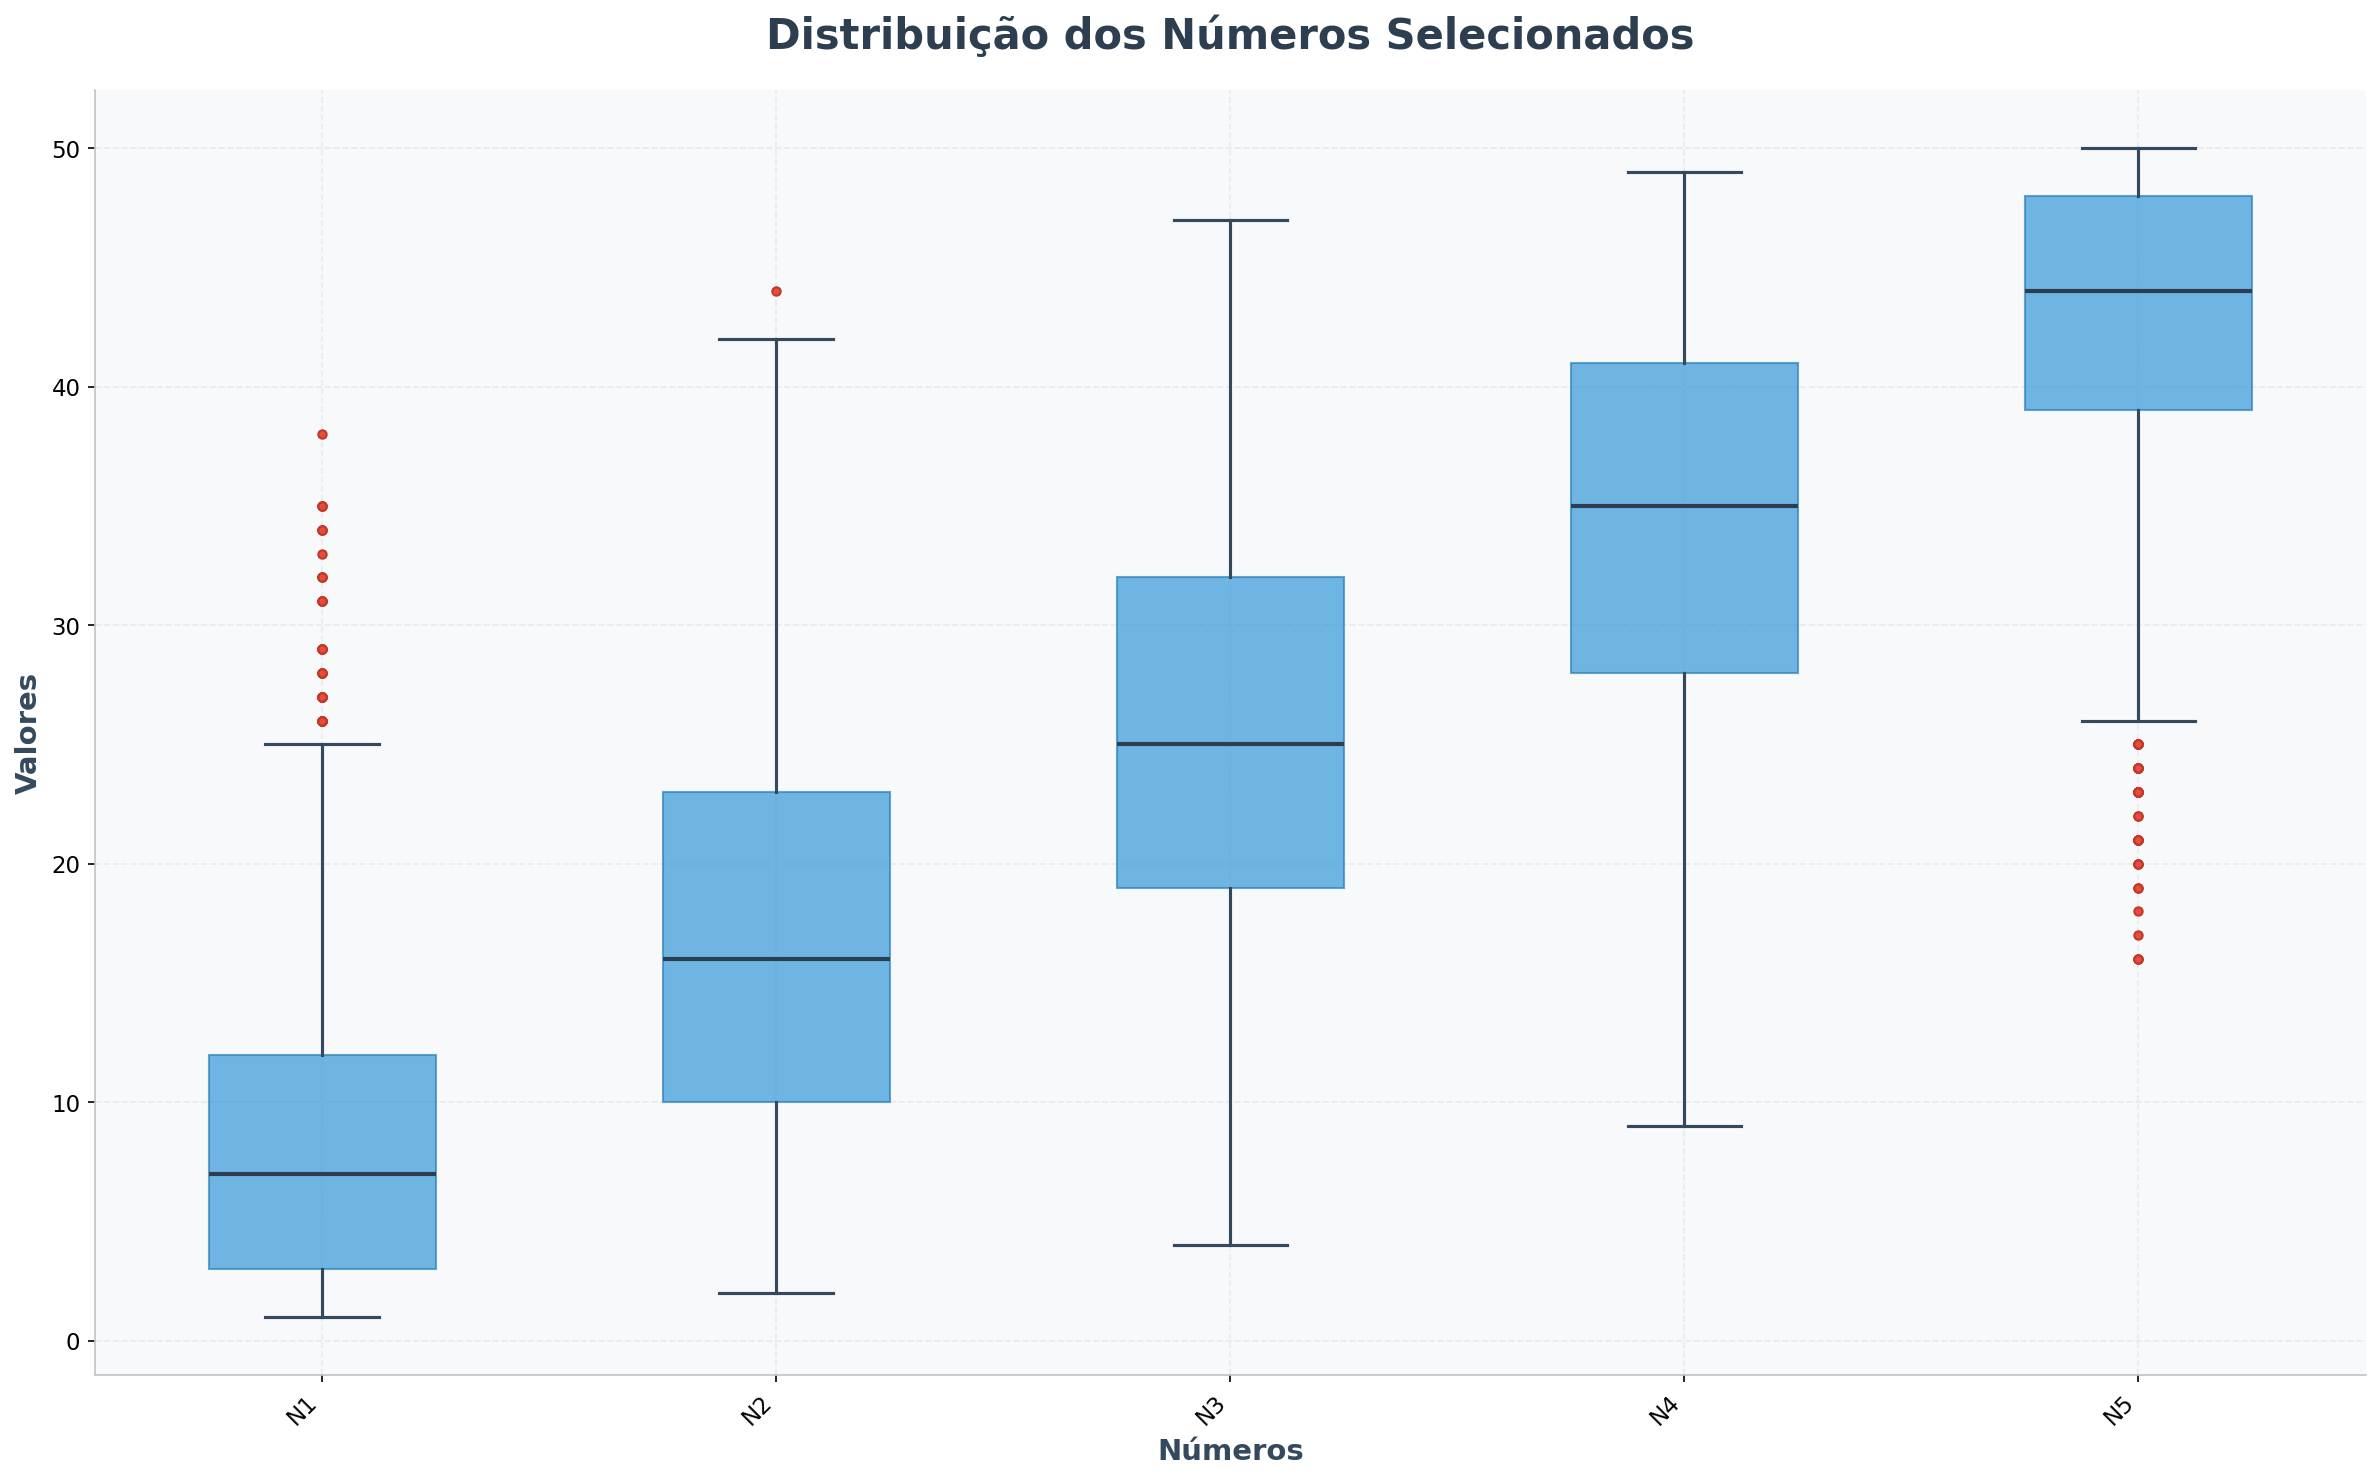

In [6]:
plot_boxplot(df_numeros, titulo='Distribuição dos Números Selecionados')

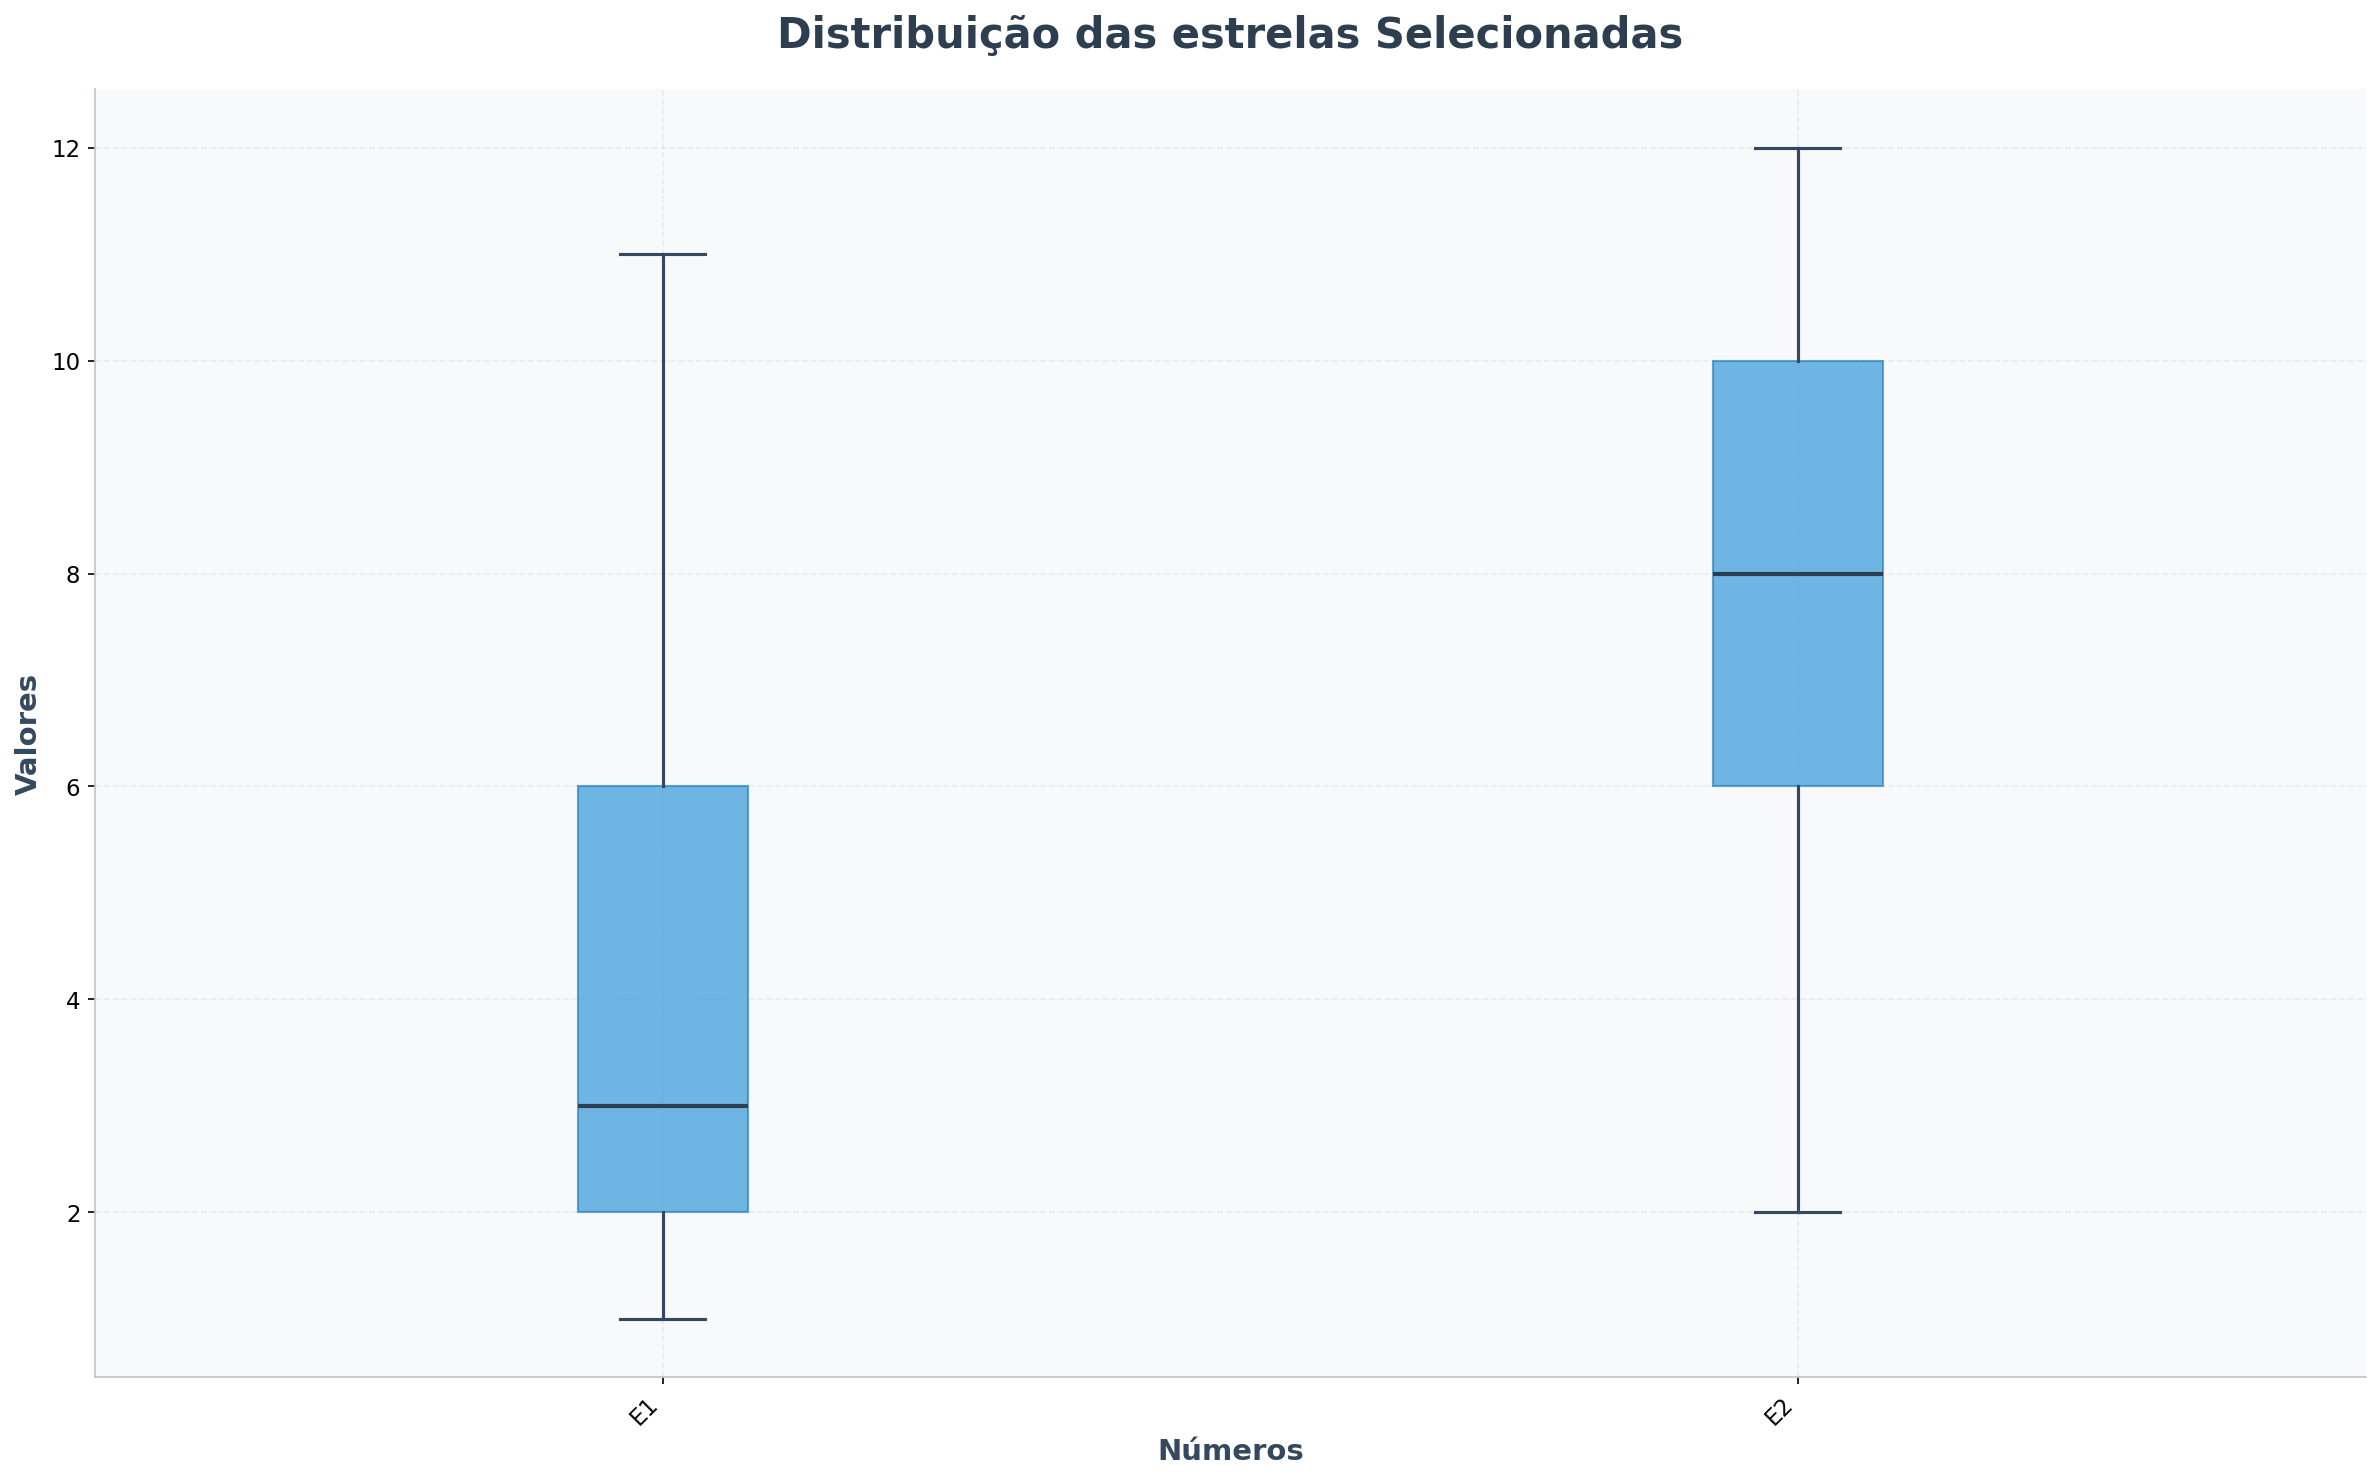

In [7]:
plot_boxplot(df_estrelas, titulo='Distribuição das estrelas Selecionadas')

## 2.2. ViolinPlot

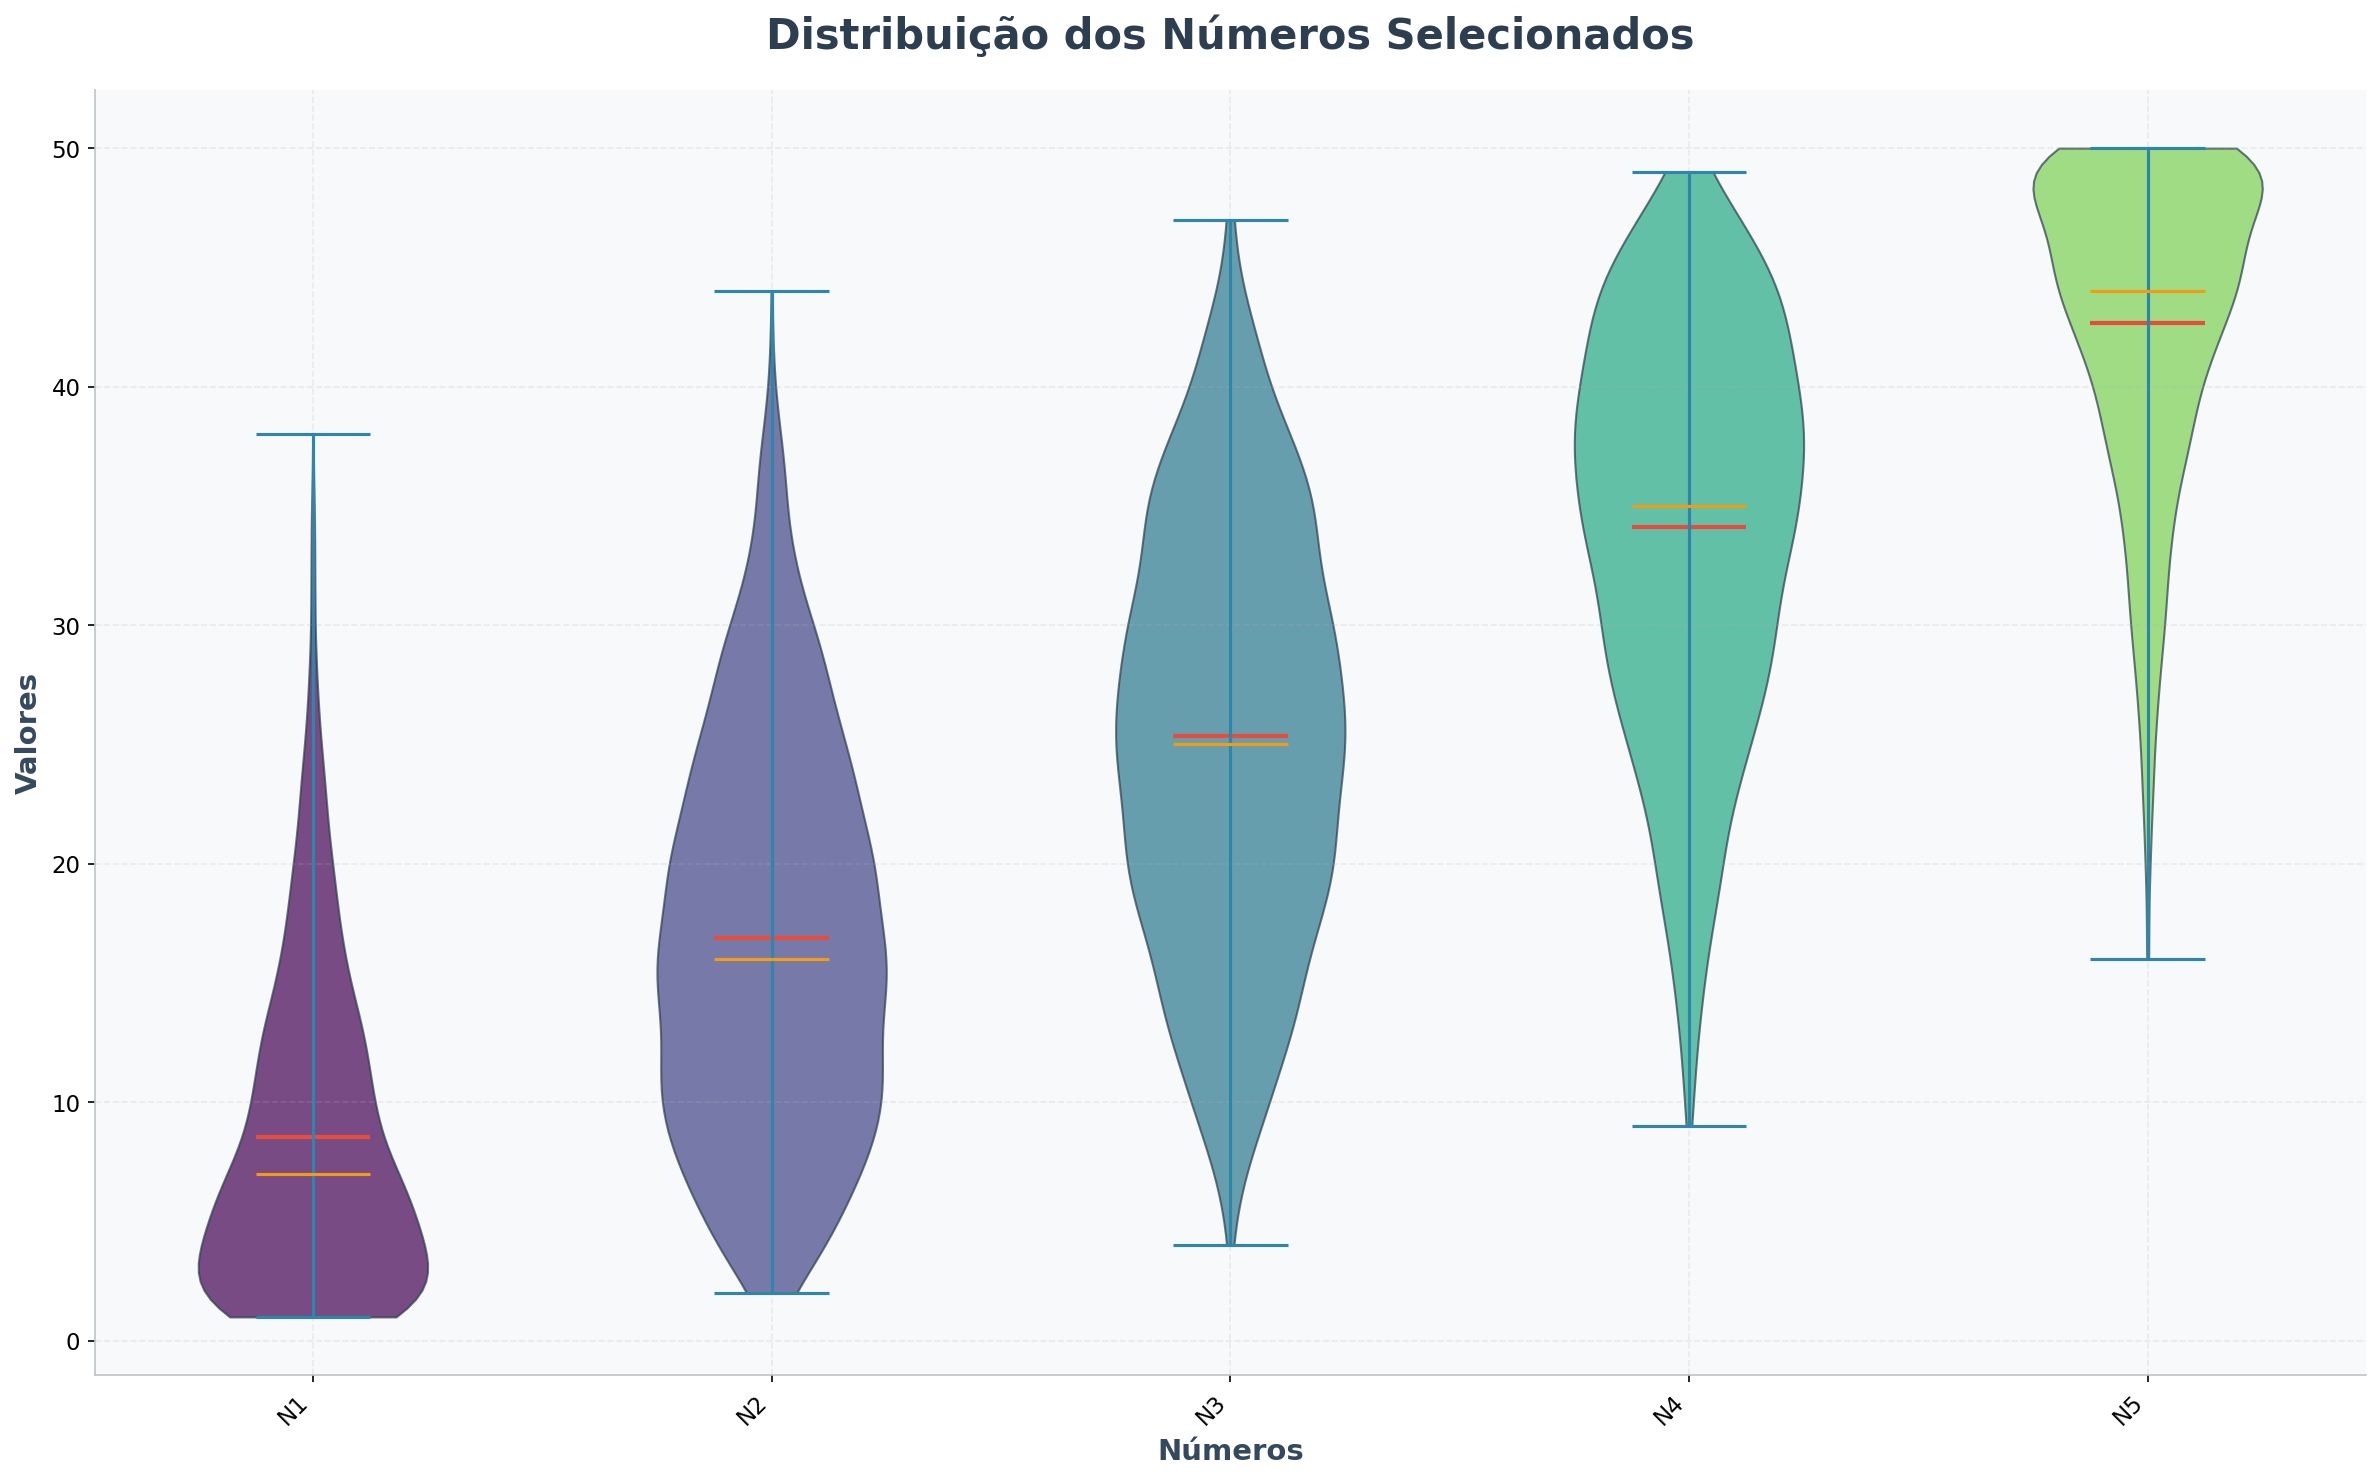

In [8]:
plot_violinplot(df_numeros, titulo='Distribuição dos Números Selecionados')

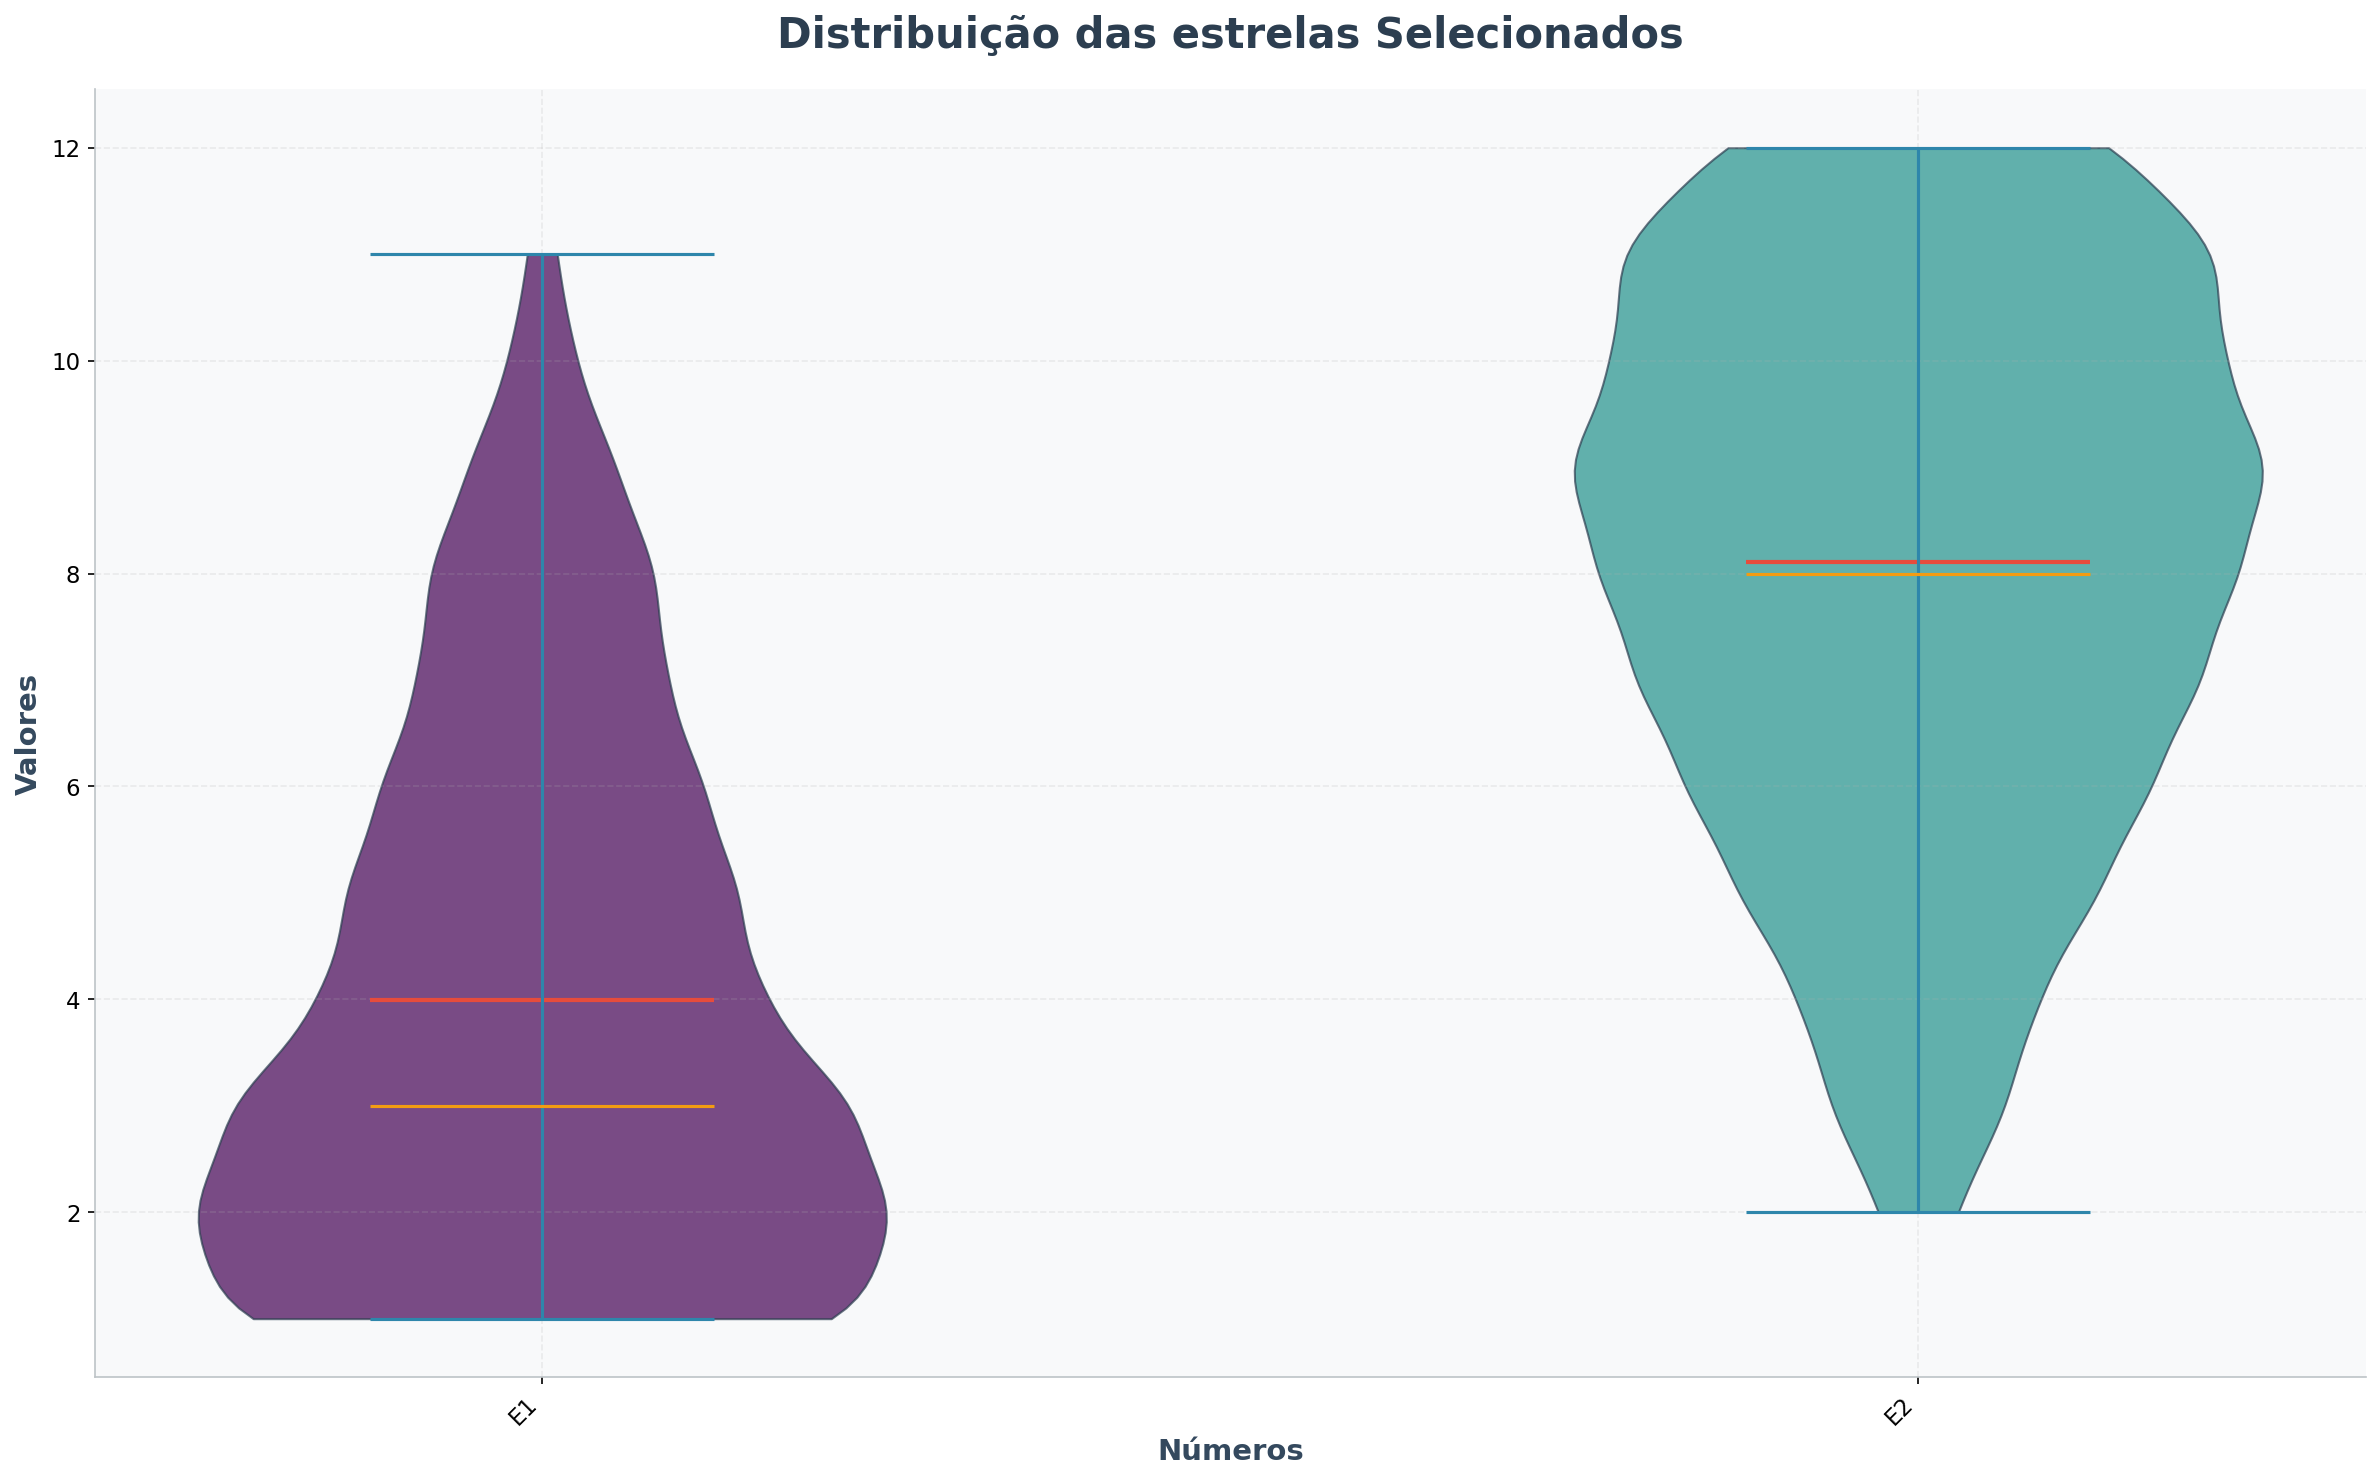

In [9]:
plot_violinplot(df_estrelas, titulo='Distribuição das estrelas Selecionados')

## 2.3. LinePlot

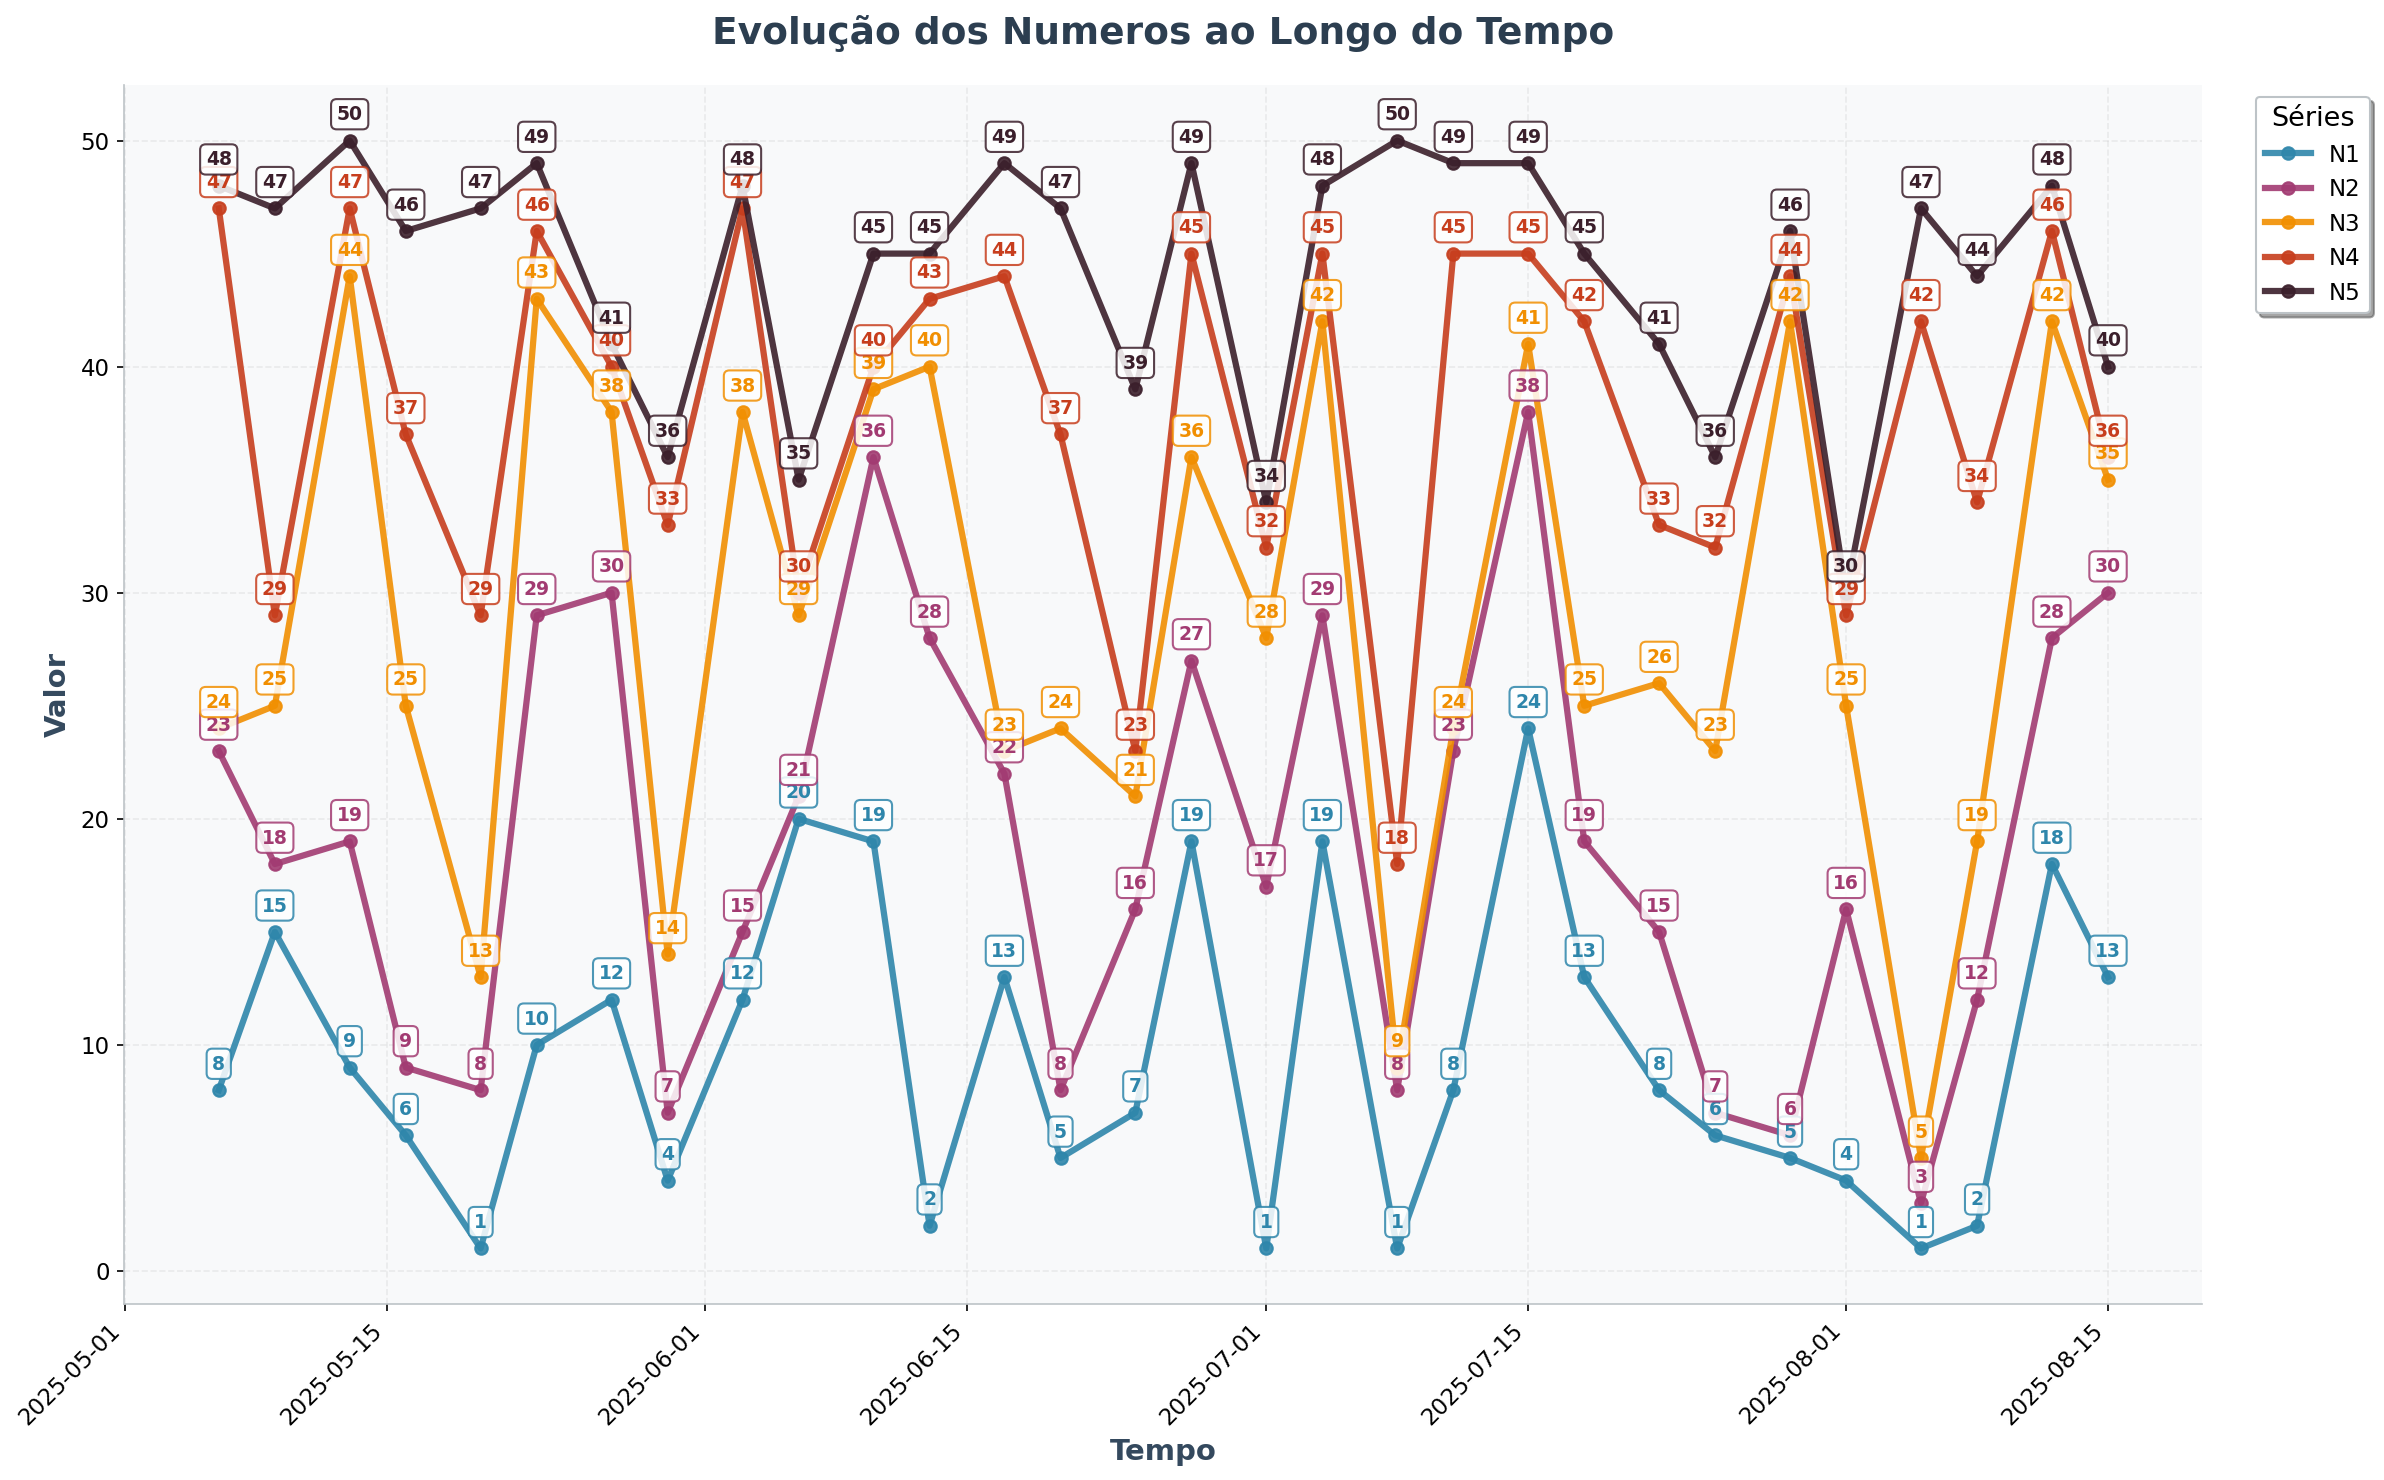

In [10]:
plot_lineplot(df, colunas=df_numeros.columns, coluna_data='date', titulo='Evolução dos Numeros ao Longo do Tempo', n_recentes=30)

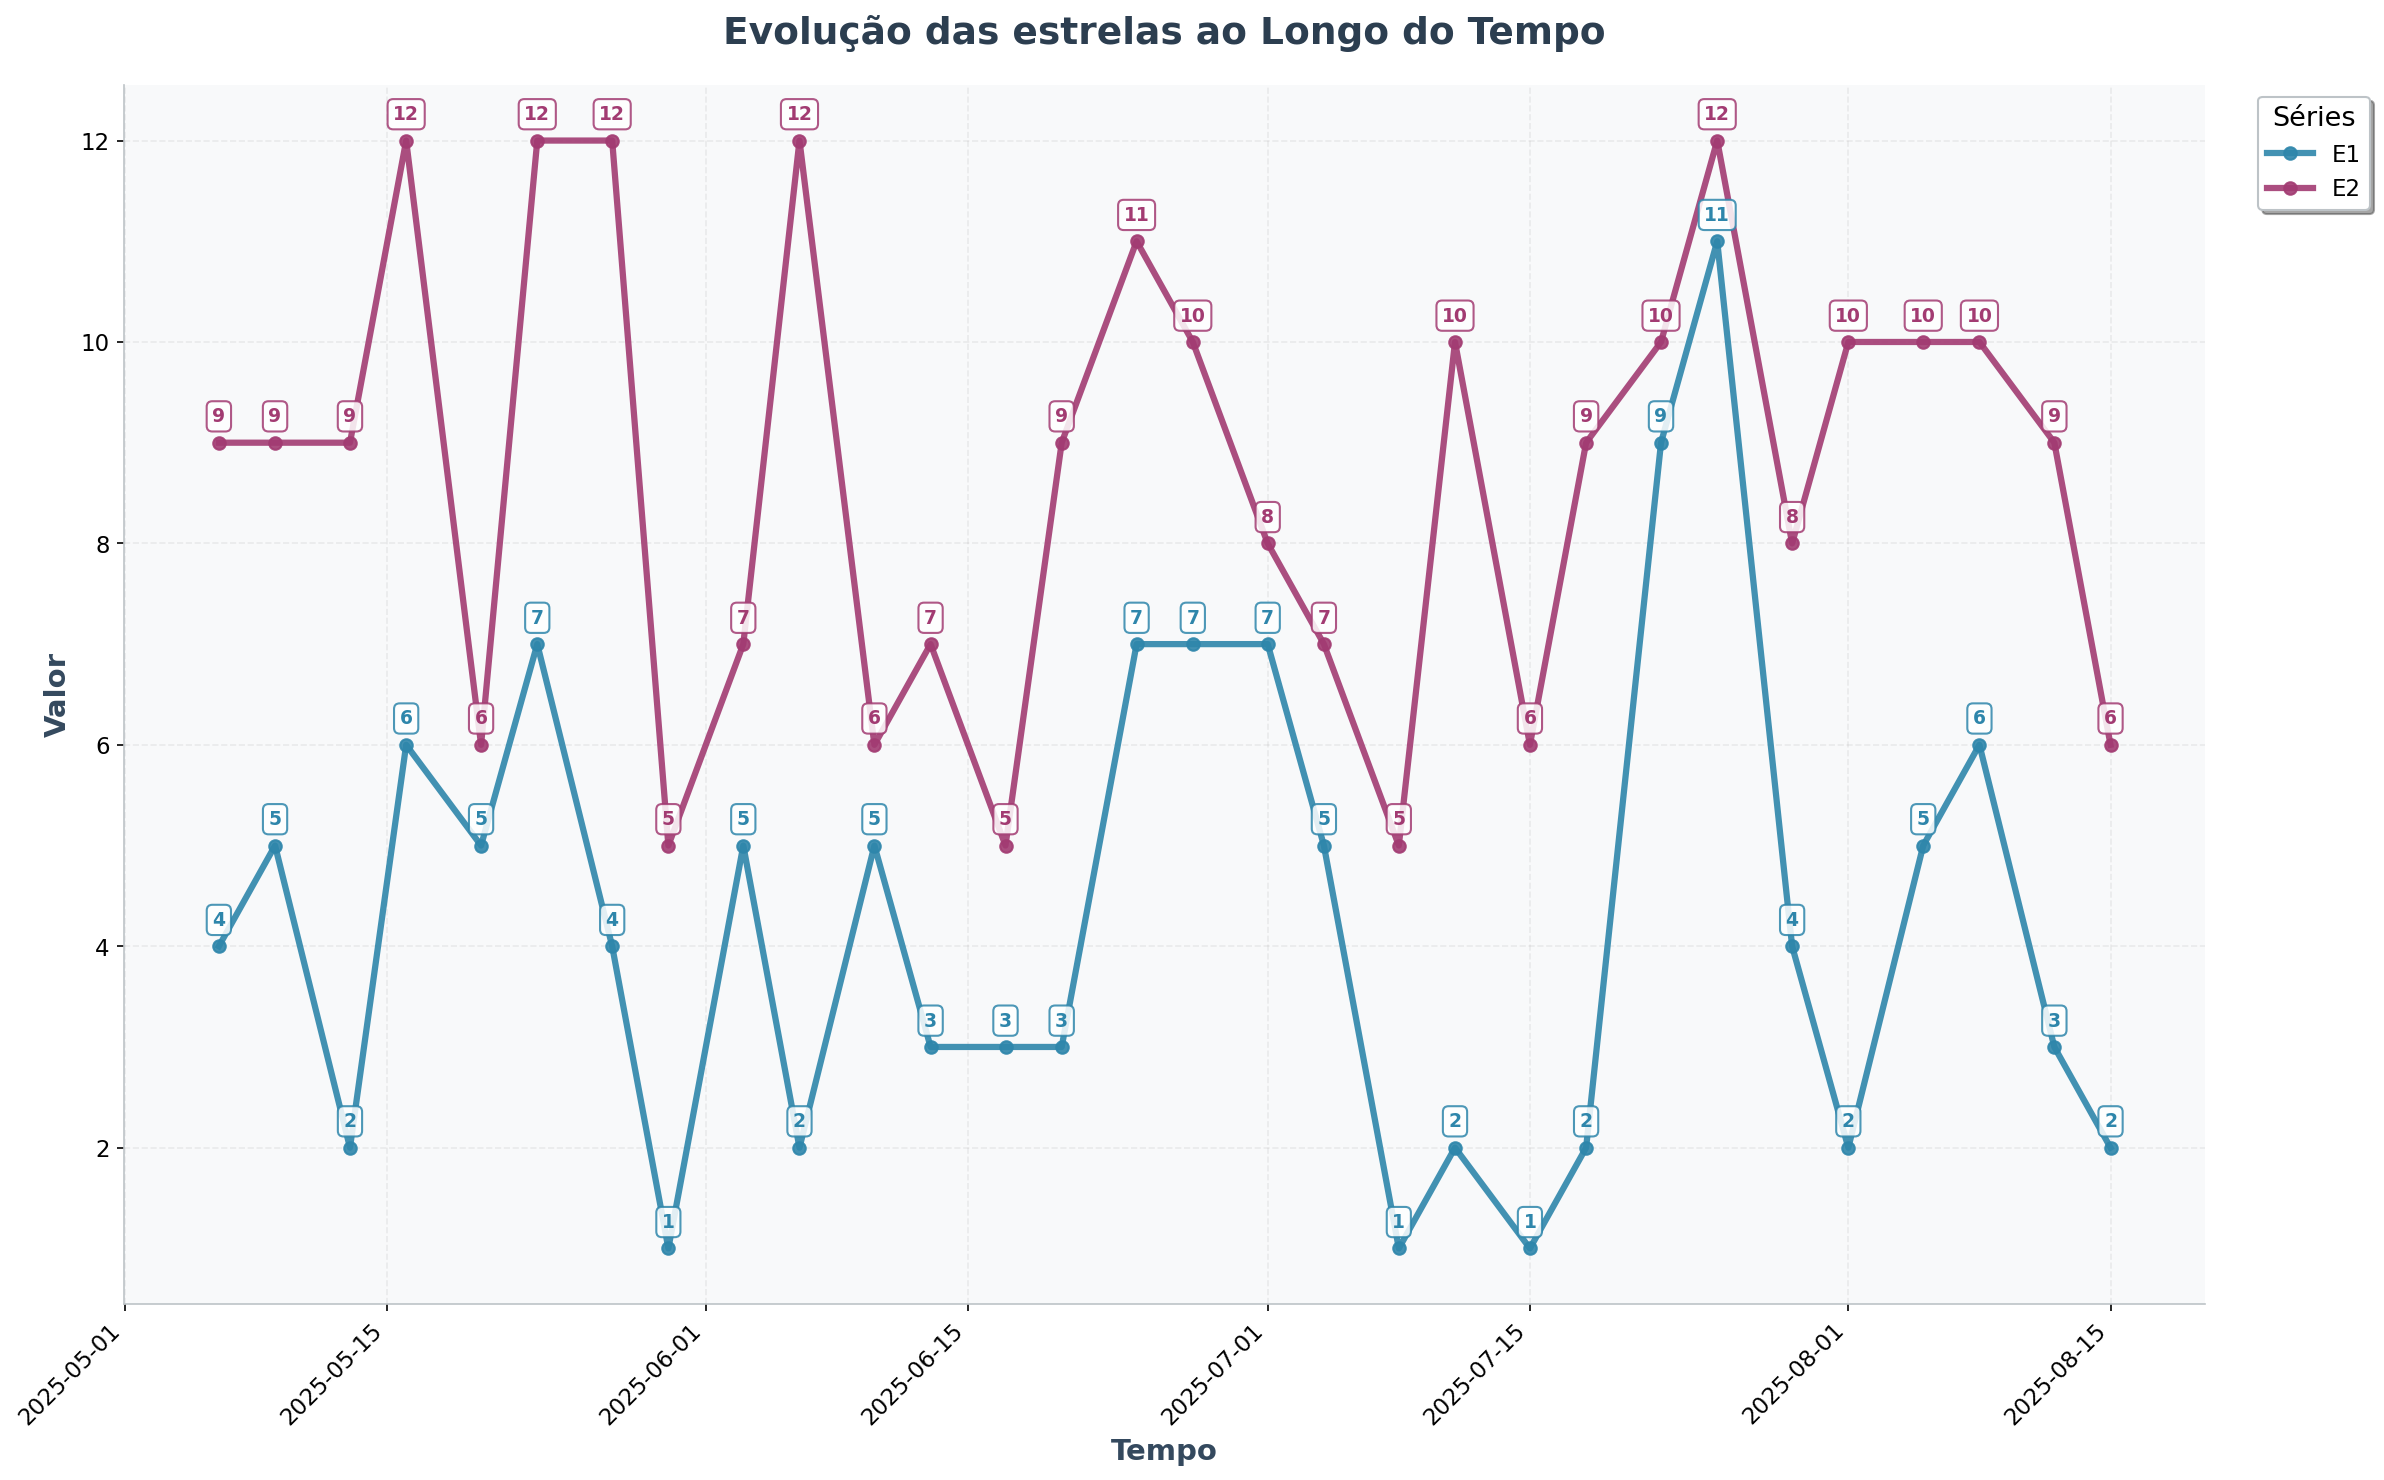

In [11]:
plot_lineplot(df, colunas=df_estrelas.columns, coluna_data='date', titulo='Evolução das estrelas ao Longo do Tempo', n_recentes=30)

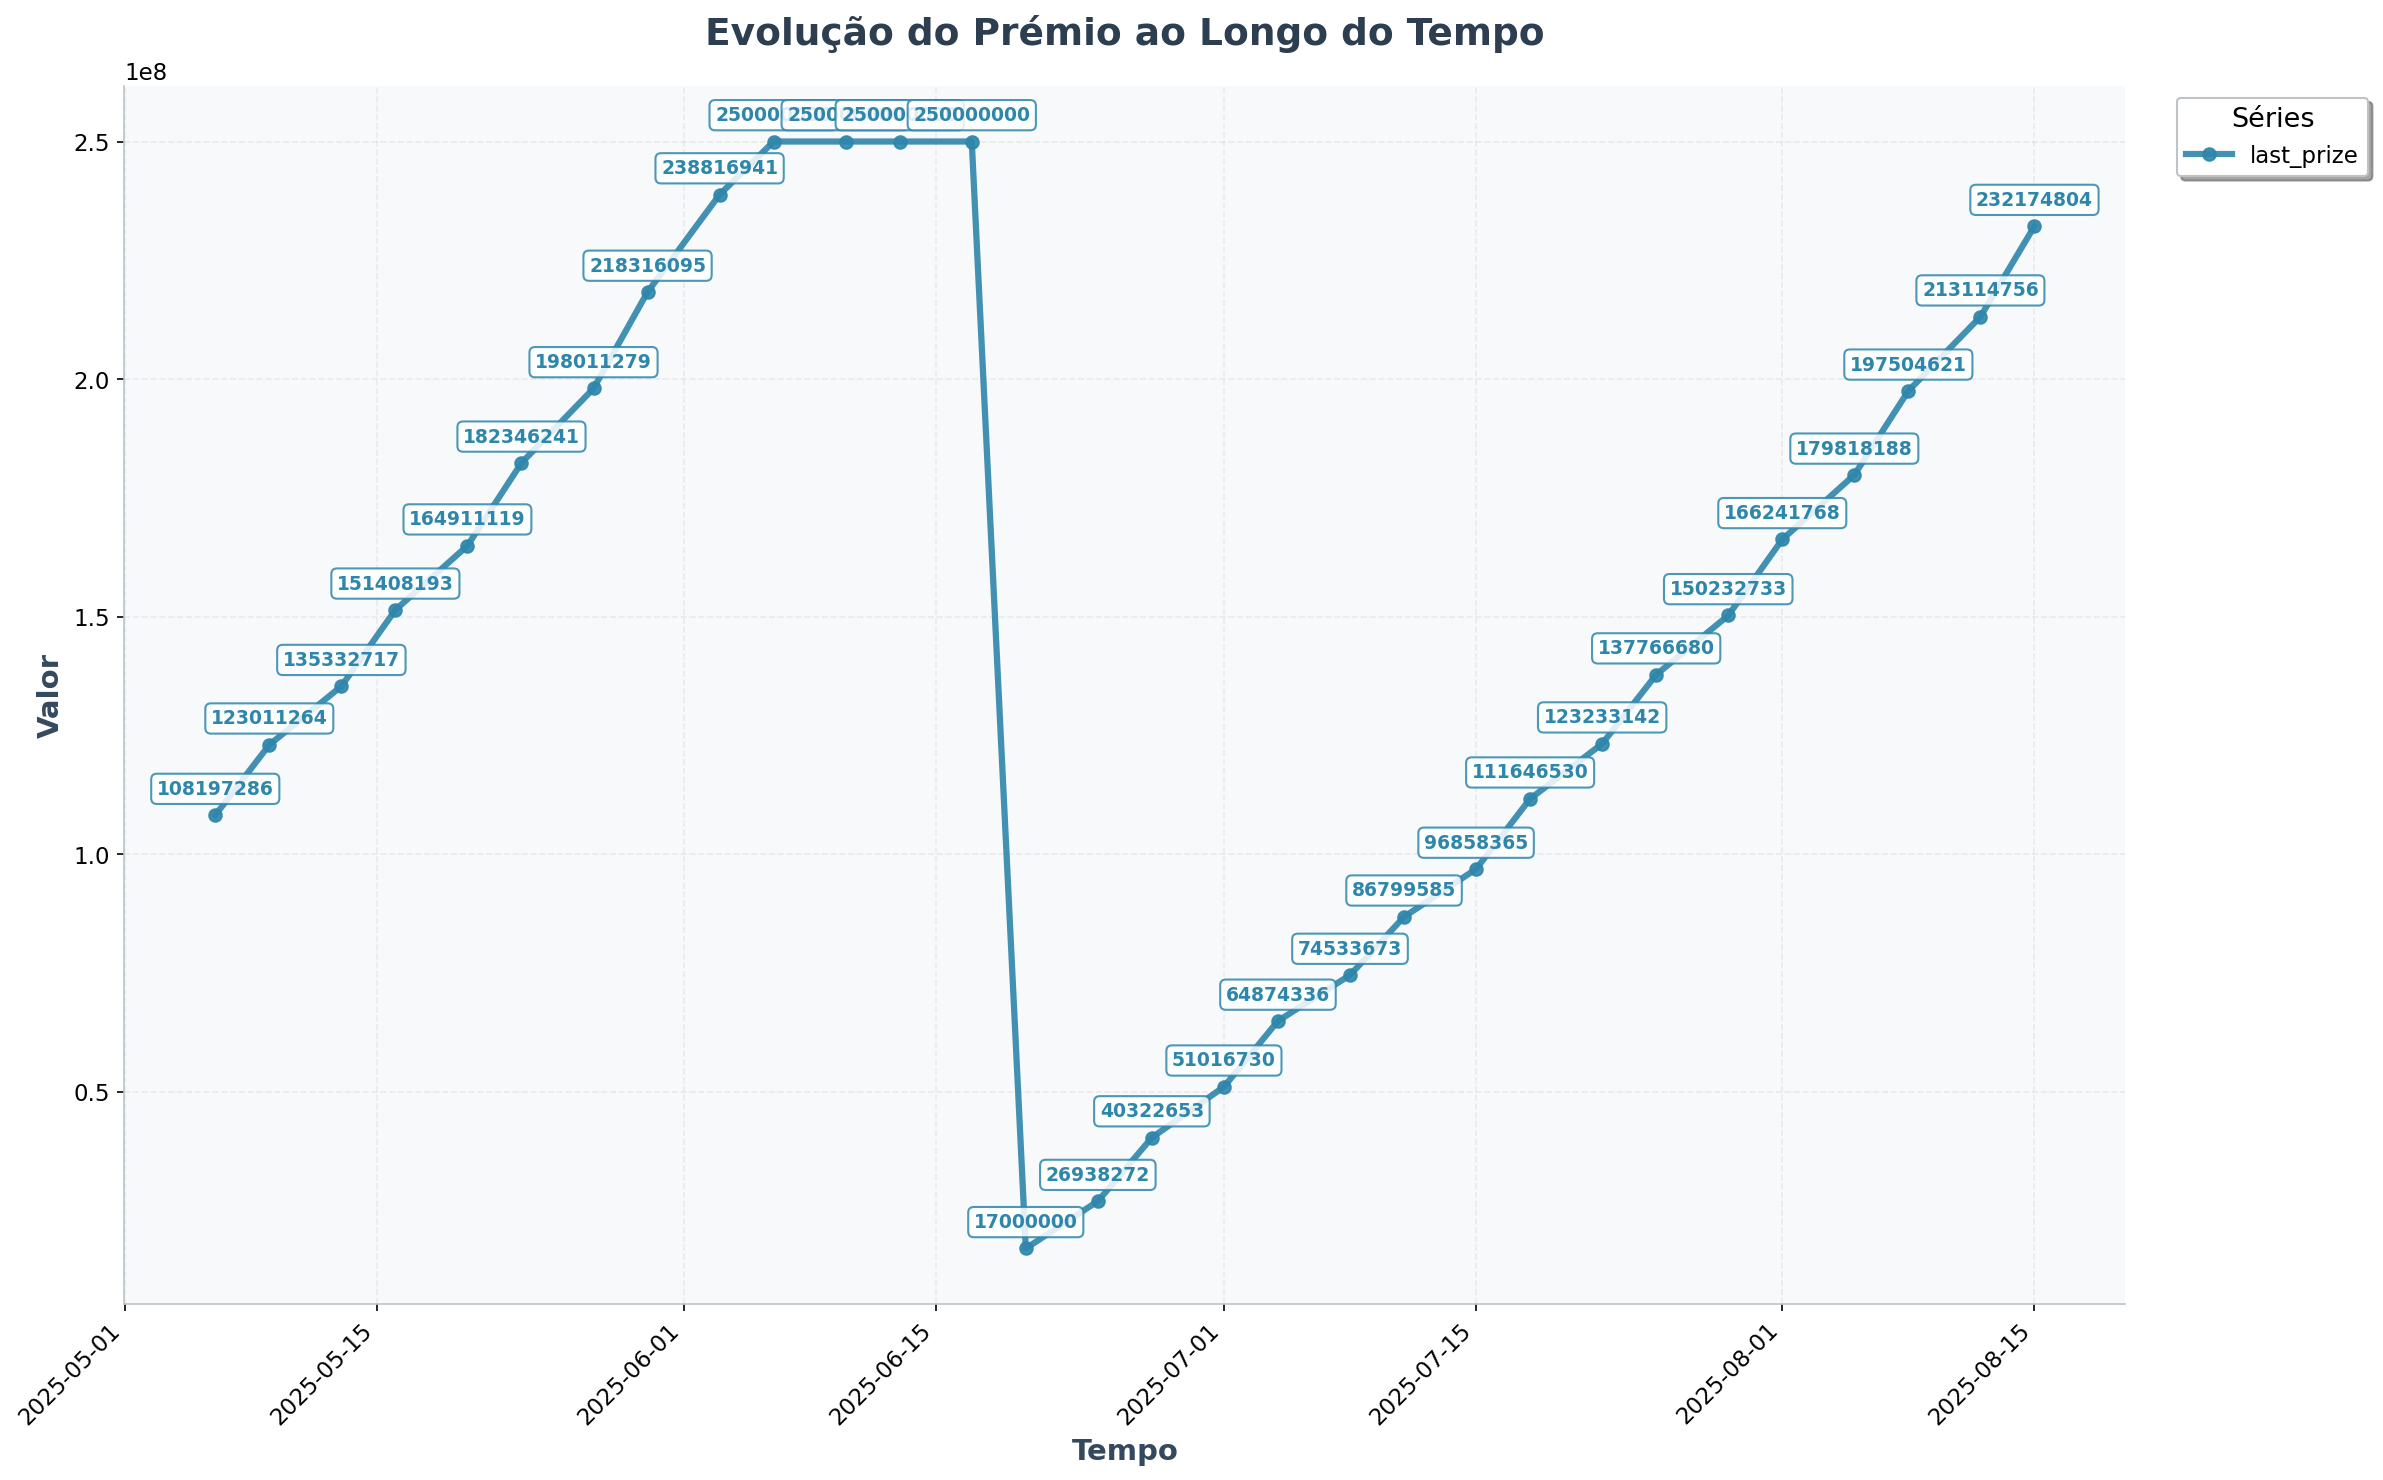

In [12]:
plot_lineplot(df, colunas="last_prize", coluna_data='date', titulo='Evolução do Prémio ao Longo do Tempo', n_recentes=30)

## 2.3. Histograma

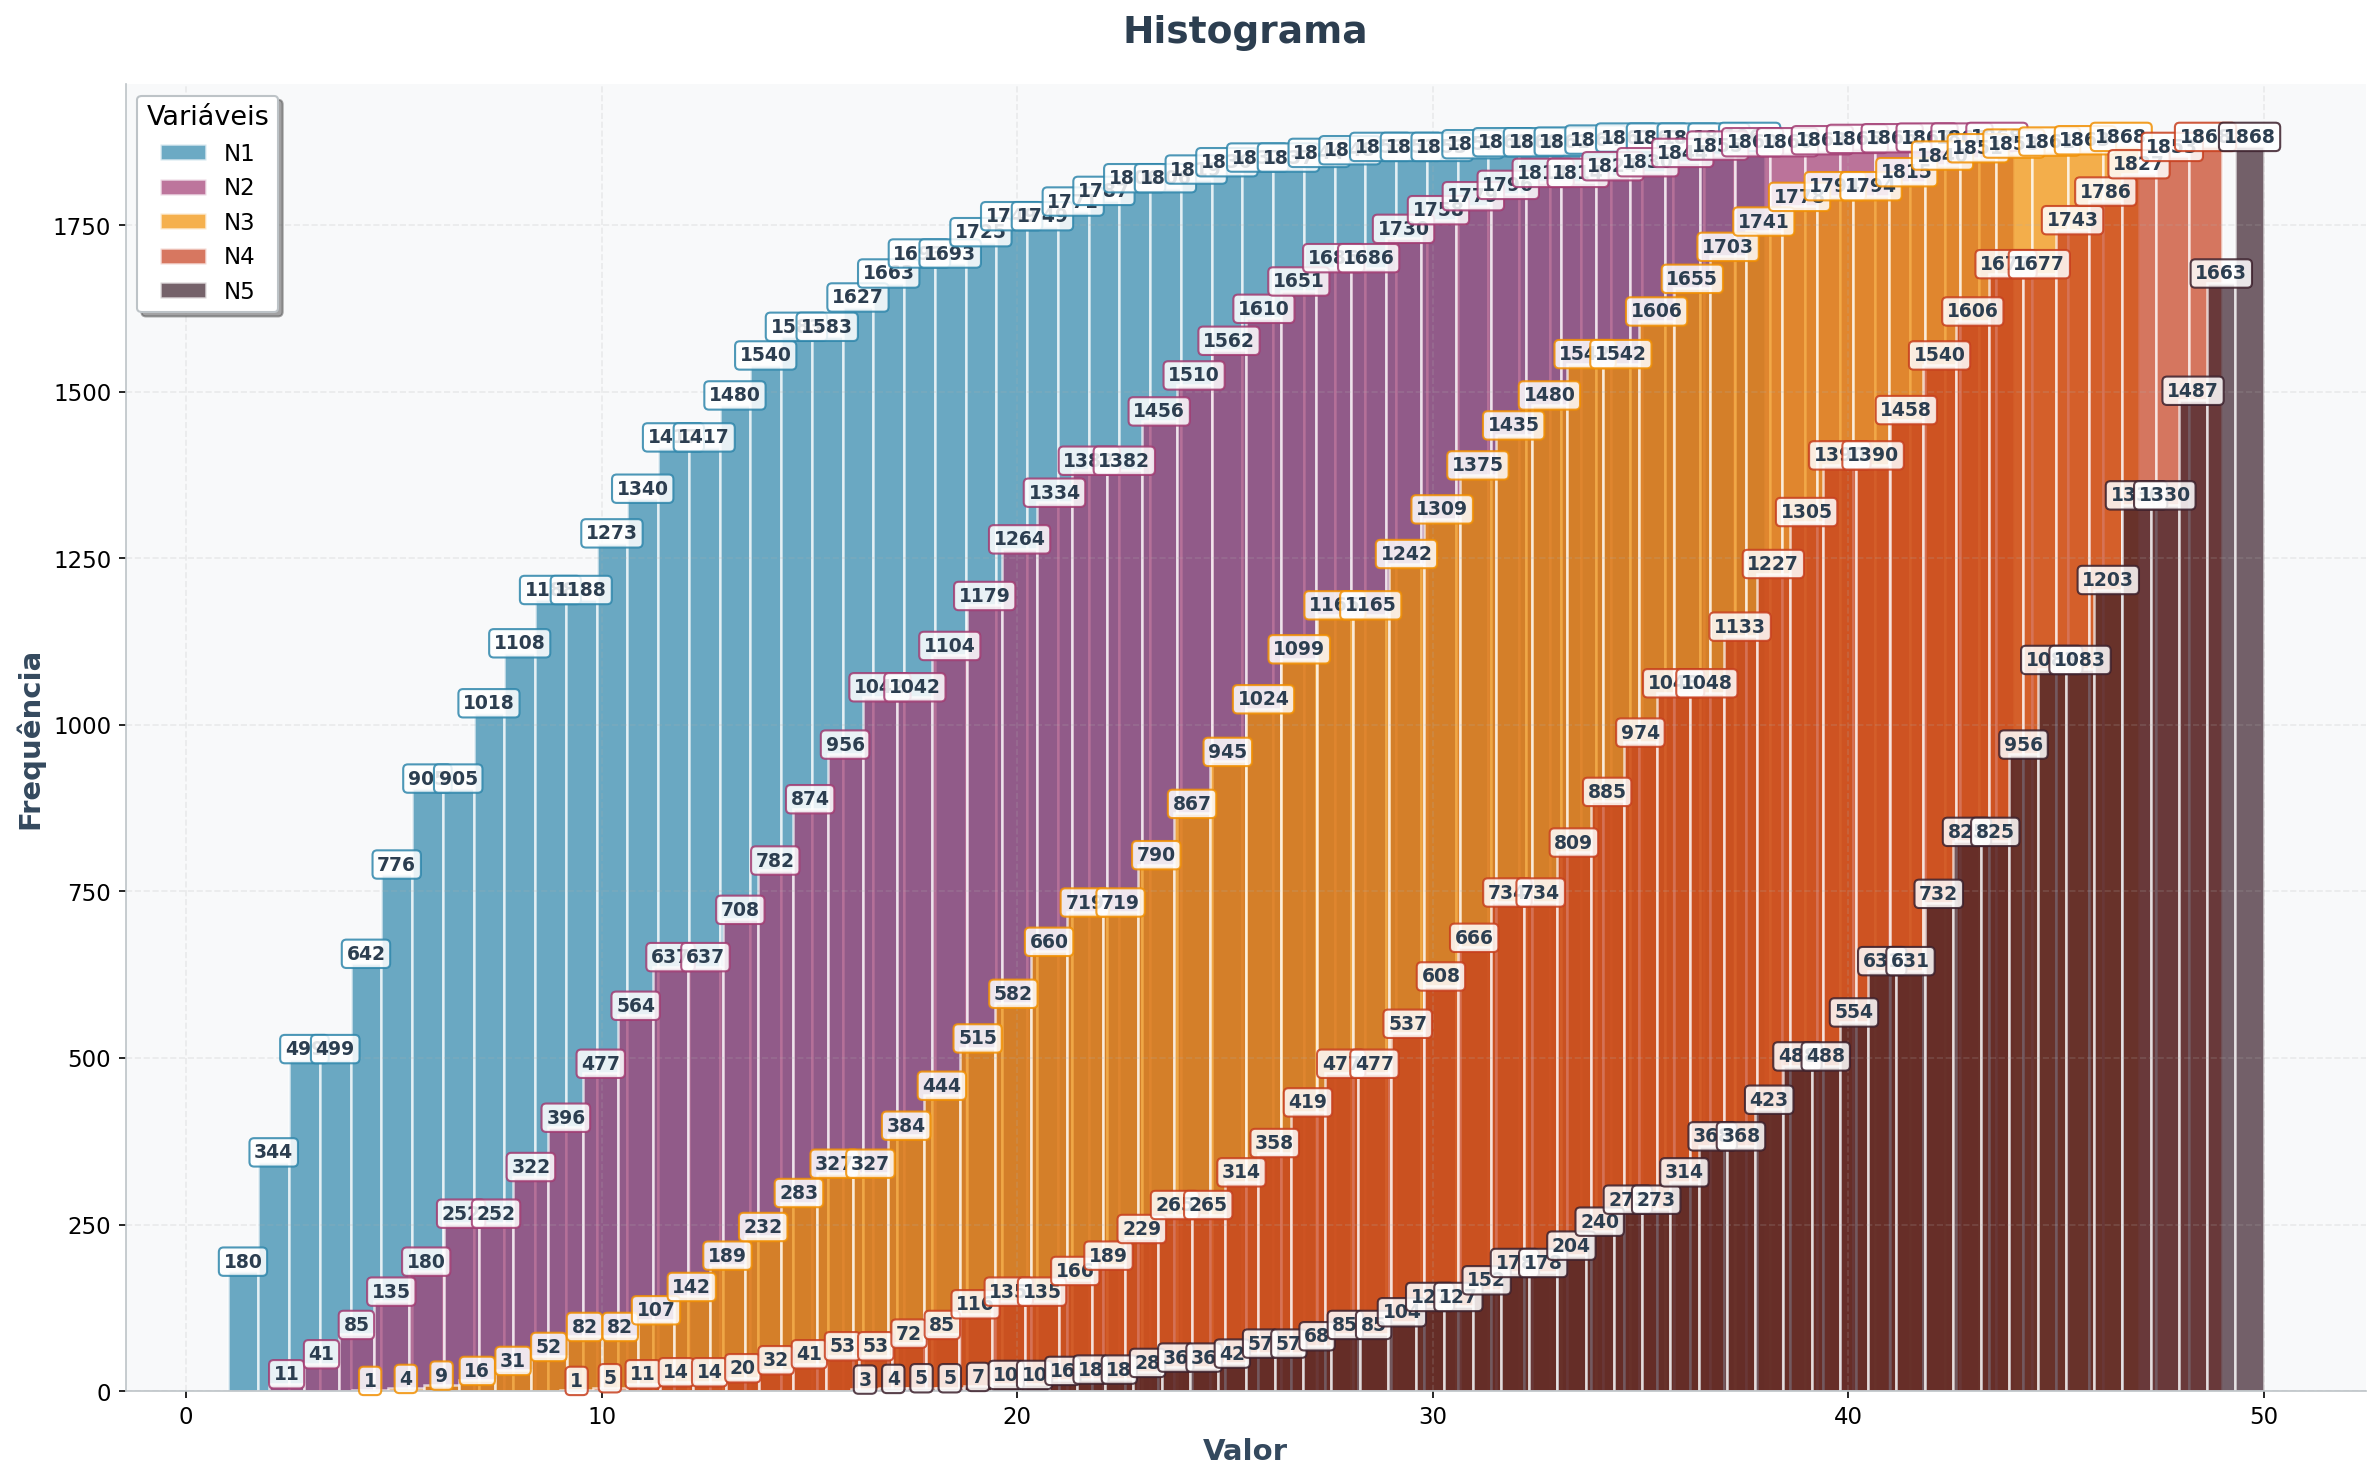

In [13]:
plot_histogram(df, colunas=df_numeros.columns, titulo='Histograma', bins=50, densidade=False, acumulado=True, mostrar_valores=True)

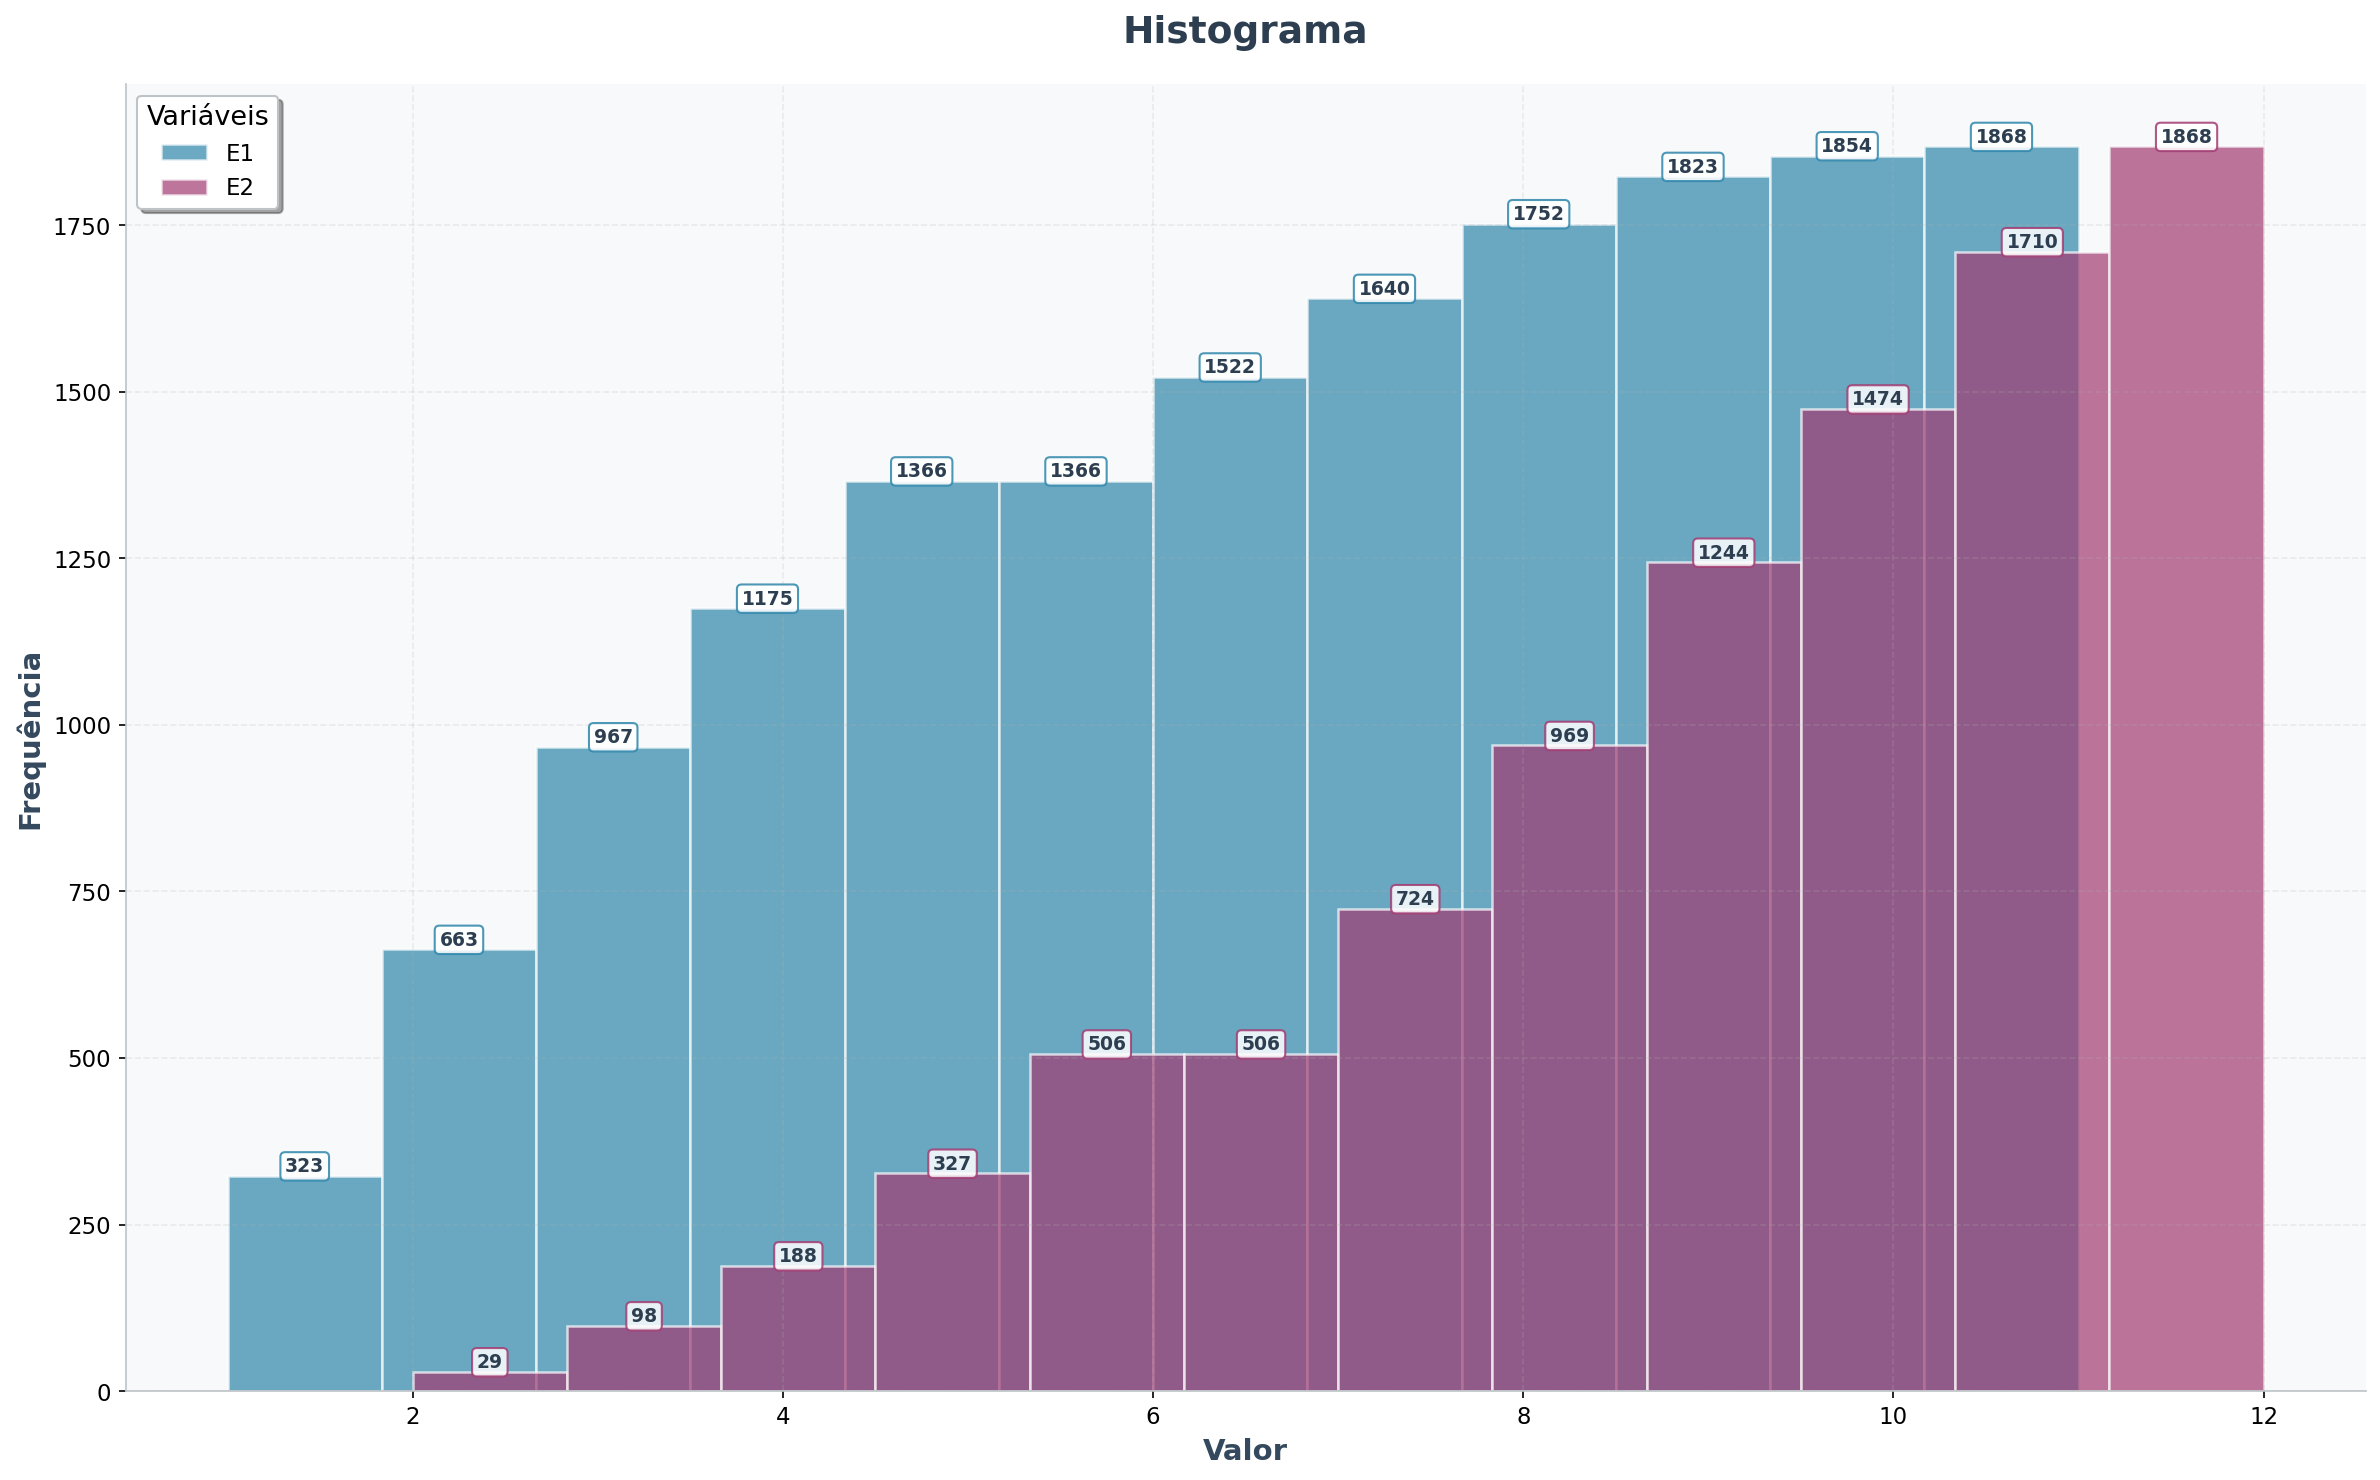

In [14]:
plot_histogram(df, colunas=df_estrelas.columns, titulo='Histograma', bins=12, densidade=False, acumulado=True, mostrar_valores=True)

## 2.4. Barplot

C:\Users\diogo\Desktop\EuroMillions\src\Graphics.py:353: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  serie = pd.to_numeric(df[c], errors='ignore')


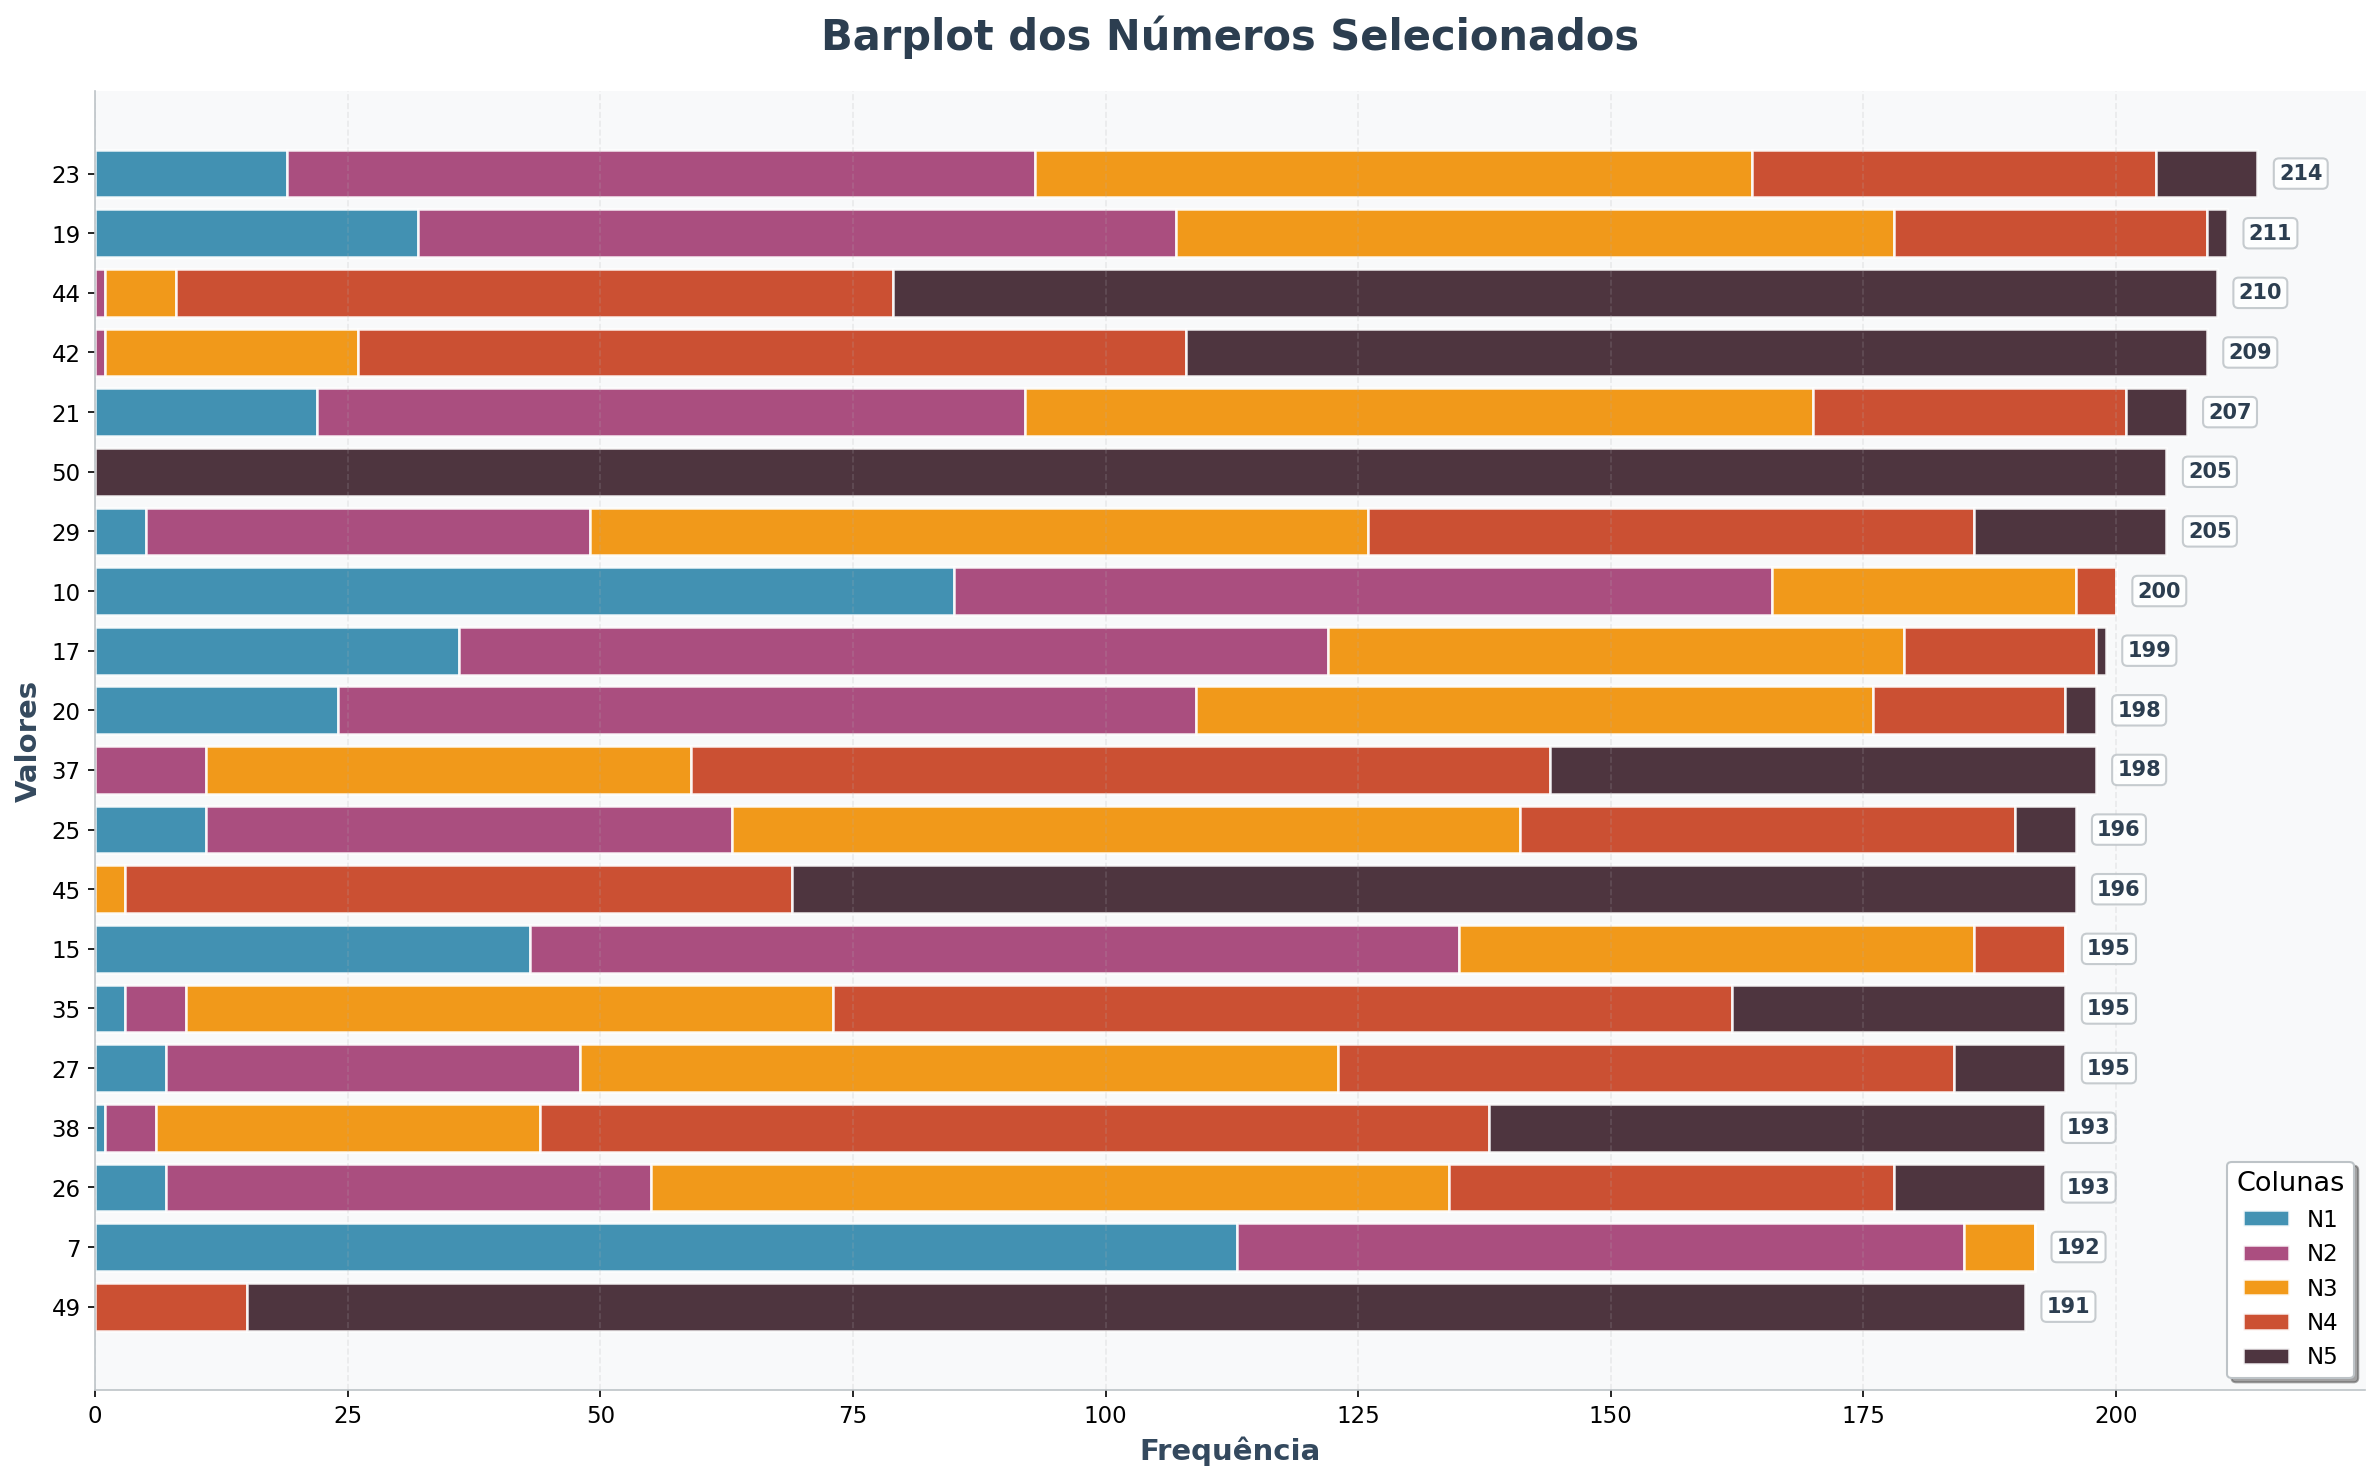

In [15]:
plot_barplot(df, df_numeros.columns, top_n=20, orientacao='horizontal', titulo="Barplot dos Números Selecionados")

C:\Users\diogo\Desktop\EuroMillions\src\Graphics.py:353: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  serie = pd.to_numeric(df[c], errors='ignore')


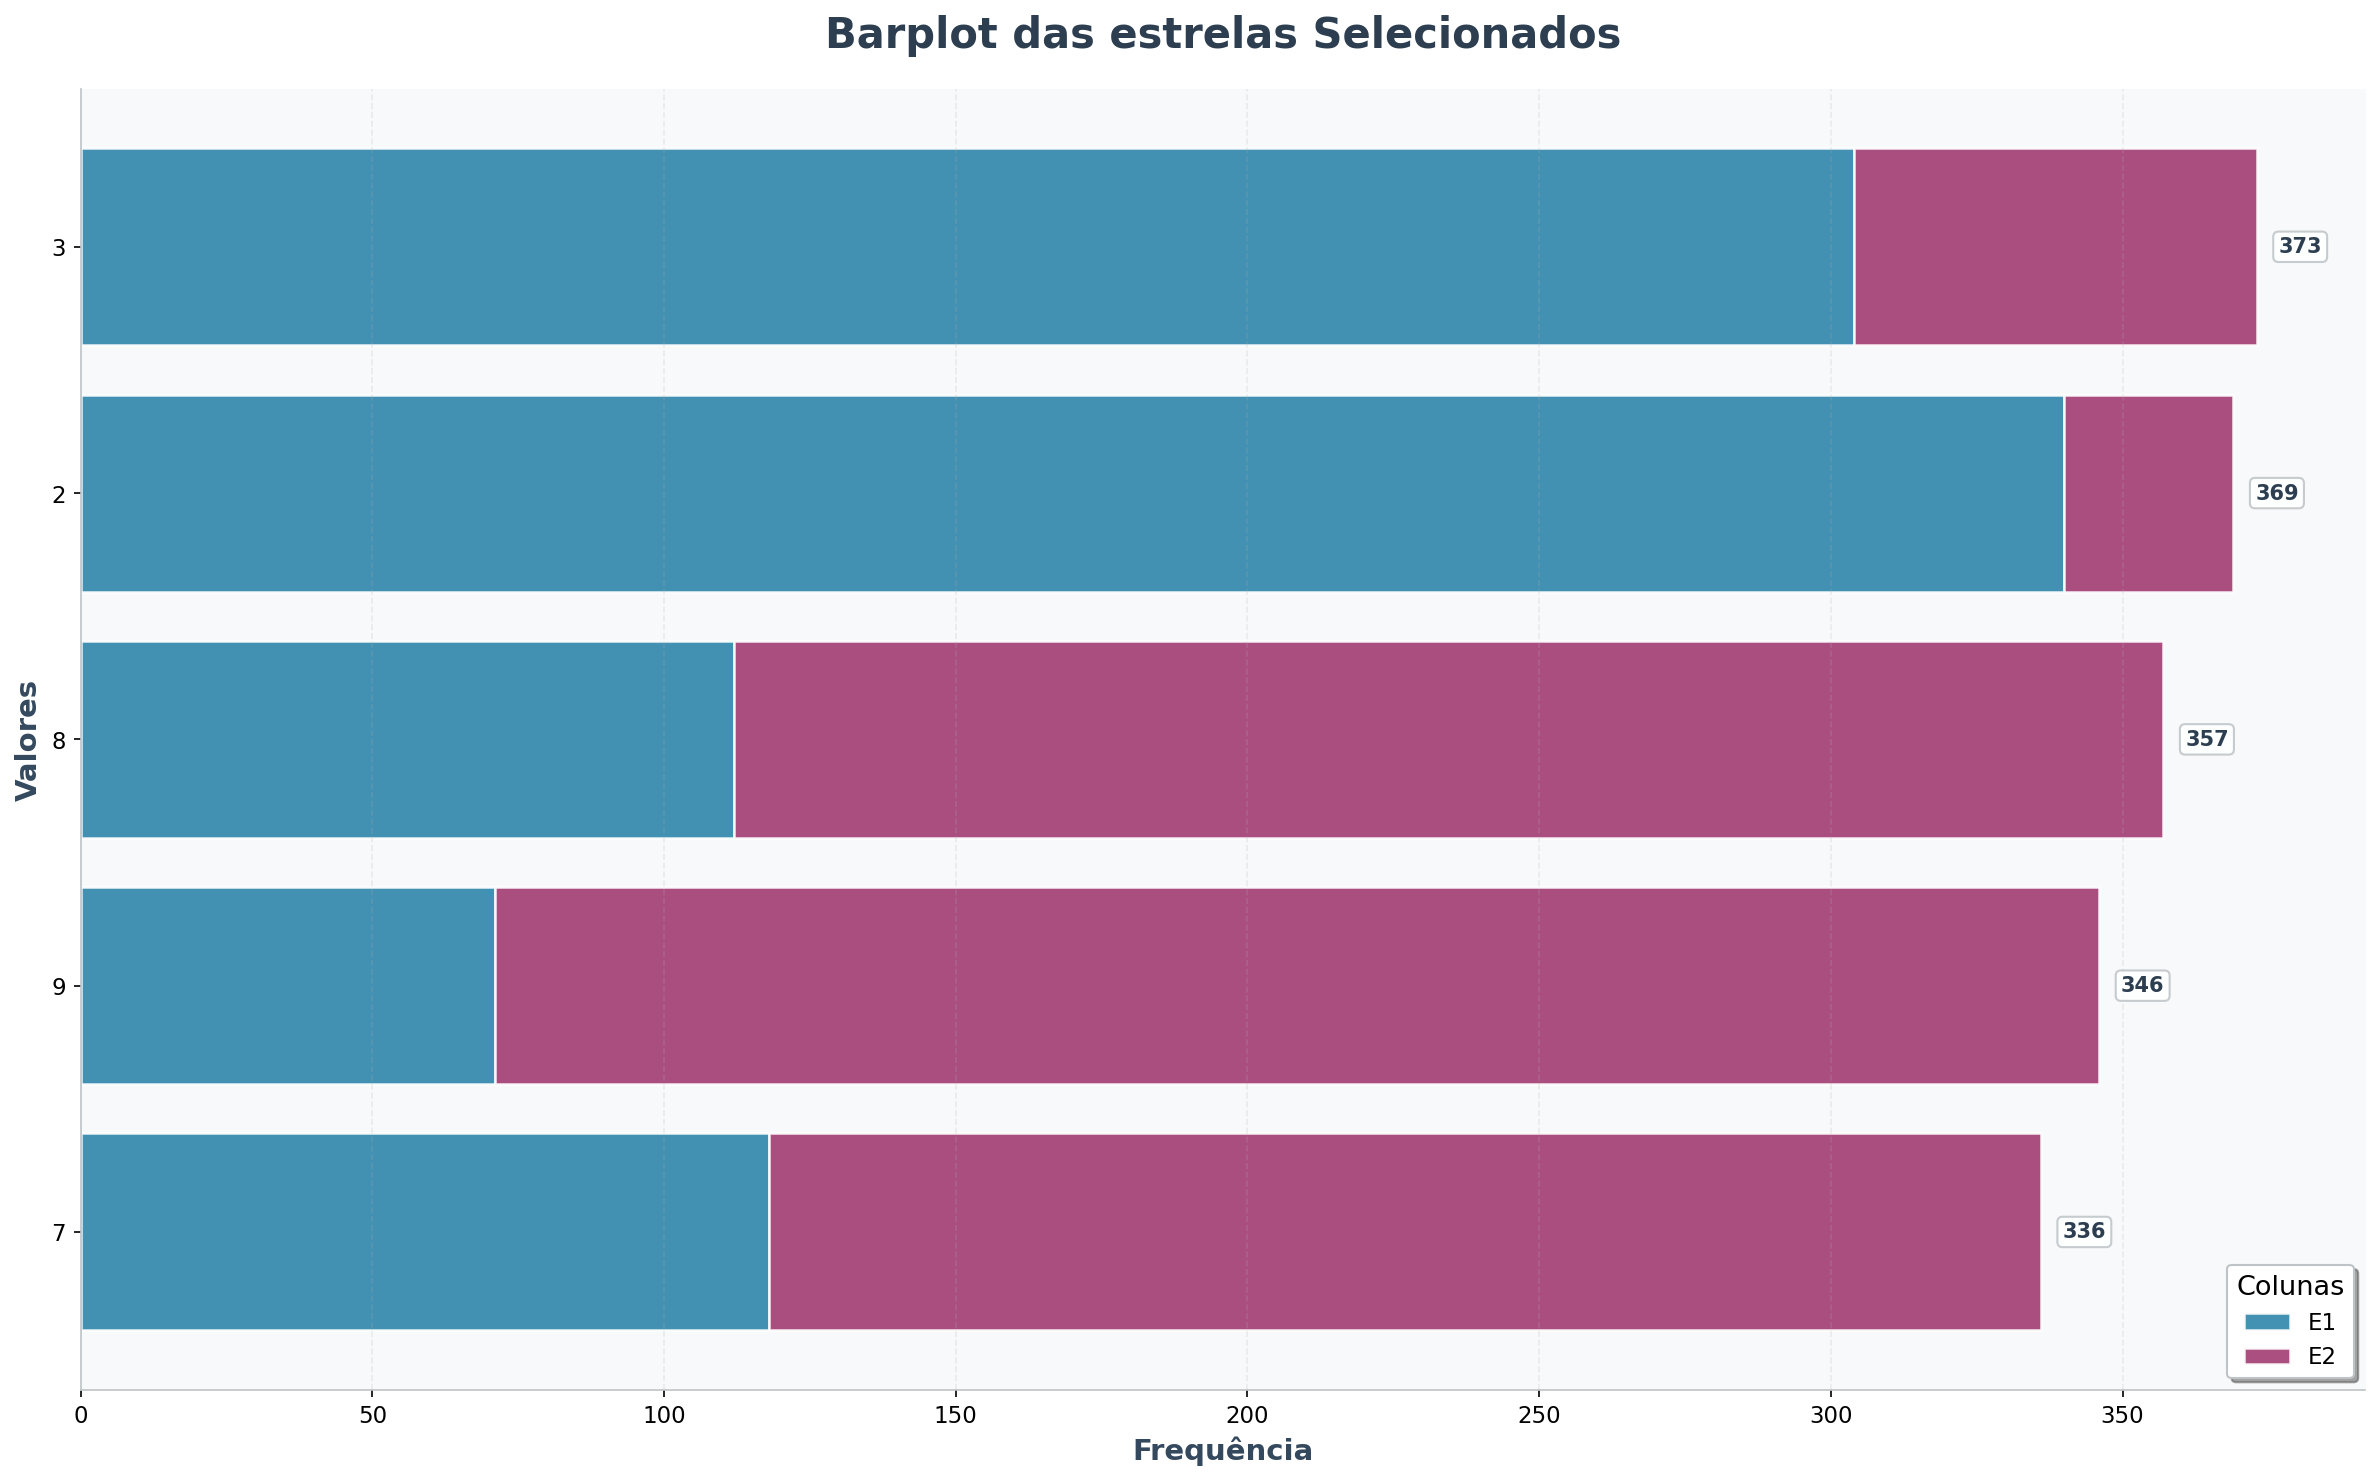

In [16]:
plot_barplot(df, df_estrelas.columns, top_n=5, orientacao='horizontal', titulo="Barplot das estrelas Selecionados")

## 2.5. PiePlot

In [17]:
colormap = "Set3"

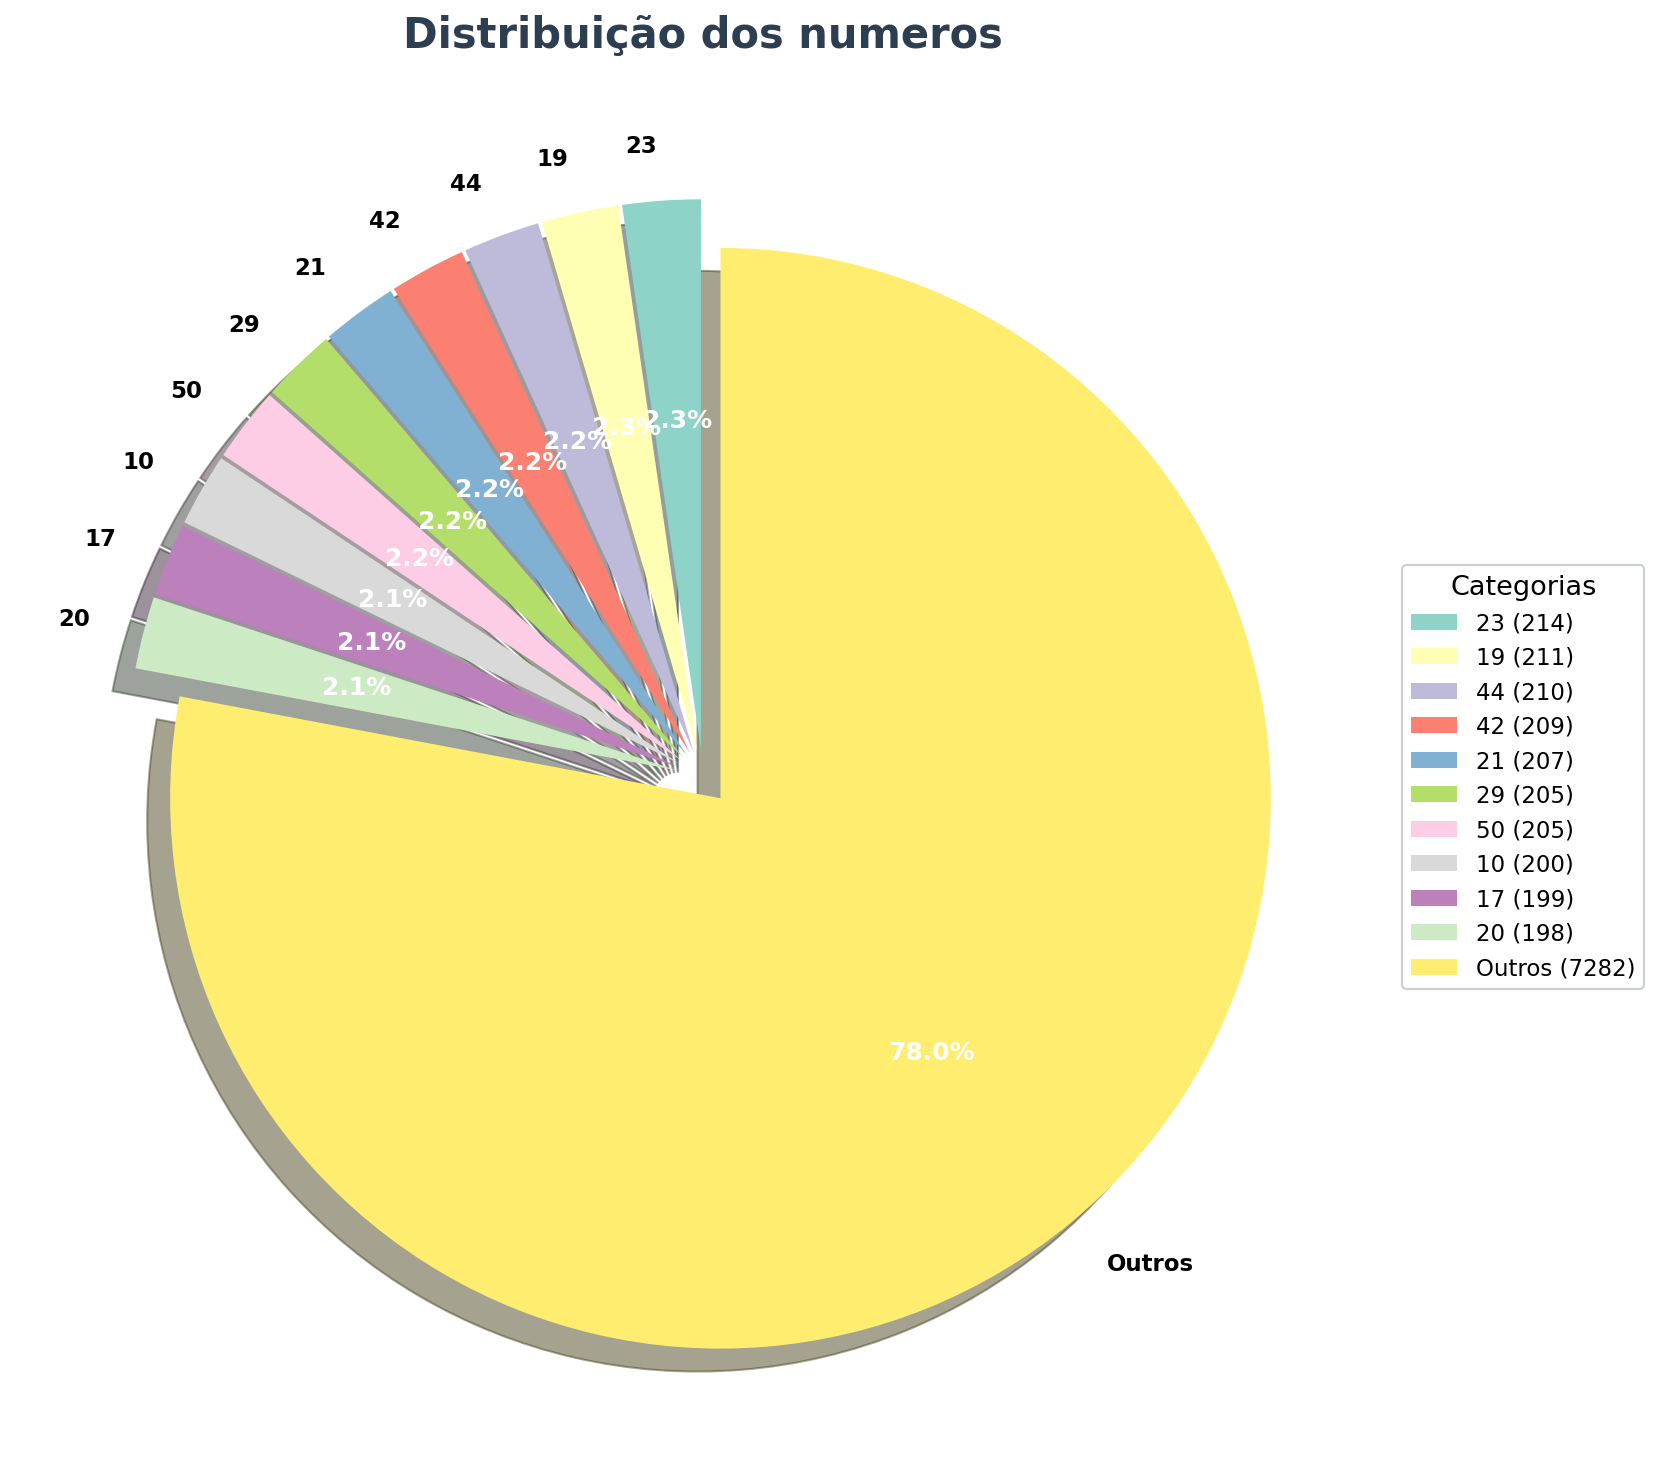

In [18]:
plot_pieplot(df, df_numeros.columns, top_n=10, titulo='Distribuição dos numeros', tipo='contagem', colormap=colormap)

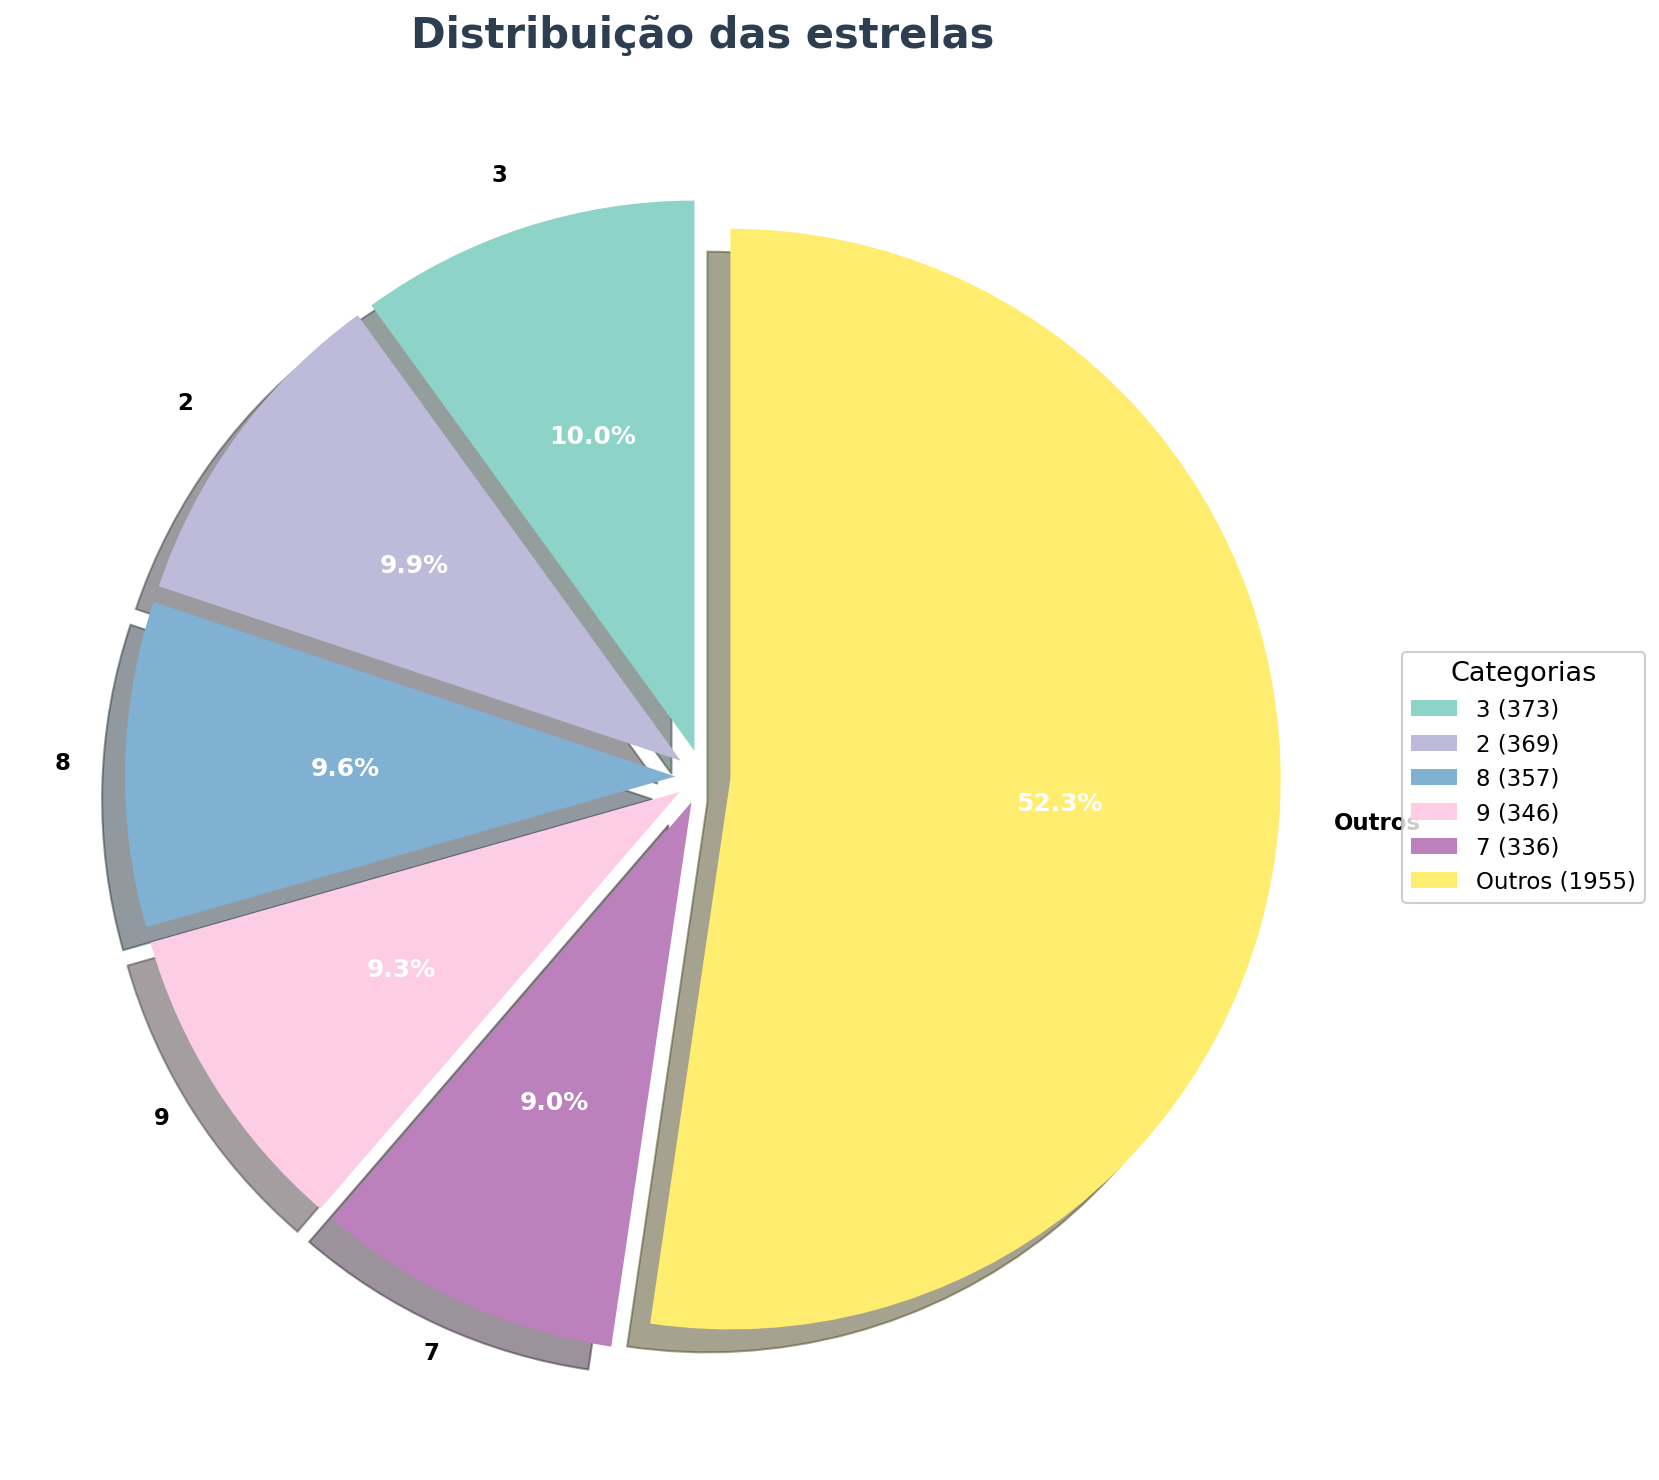

In [19]:
plot_pieplot(df, df_estrelas.columns, top_n=5, titulo='Distribuição das estrelas', tipo='contagem', colormap=colormap)

## 2.6. Correlations

In [20]:
df_corr = df[["N1", "N2", "N3", "N4", "N5", "E1", "E2", "last_prize"]]
df_corr

,N1,N2,N3,N4,N5,E1,E2,last_prize
0,16,29,32,36,41,7,9,1.500000e+07
1,7,13,39,47,50,2,5,1.500000e+07
2,14,18,19,31,37,4,5,1.775047e+07
3,4,7,33,37,39,1,5,2.067807e+07
4,15,24,28,44,47,4,5,1.500000e+07
...,...,...,...,...,...,...,...,...
1863,4,16,25,29,30,2,10,1.662418e+08
1864,1,3,5,42,47,5,10,1.798182e+08
1865,2,12,19,34,44,6,10,1.975046e+08
1866,18,28,42,46,48,3,9,2.131148e+08


In [21]:
df_corr.dtypes

N1              int64
N2              int64
N3              int64
N4              int64
N5              int64
E1              int64
E2              int64
last_prize    float64
dtype: object

### 2.6.1. Pearson

In [22]:
df_corr.corr(method='pearson')

,N1,N2,N3,N4,N5,E1,E2,last_prize
N1,1.000000,0.624502,0.436642,0.291263,0.190862,-0.019390,-0.011095,0.032719
N2,0.624502,1.000000,0.693289,0.468423,0.289963,-0.019636,-0.014402,0.031669
N3,0.436642,0.693289,1.000000,0.685519,0.419023,0.013744,0.008972,0.044276
N4,0.291263,0.468423,0.685519,1.000000,0.626296,0.012167,0.024352,0.065152
N5,0.190862,0.289963,0.419023,0.626296,1.000000,0.011300,0.021330,0.021022
E1,-0.019390,-0.019636,0.013744,0.012167,0.011300,1.000000,0.489252,0.039107
E2,-0.011095,-0.014402,0.008972,0.024352,0.021330,0.489252,1.000000,0.065723
last_prize,0.032719,0.031669,0.044276,0.065152,0.021022,0.039107,0.065723,1.000000


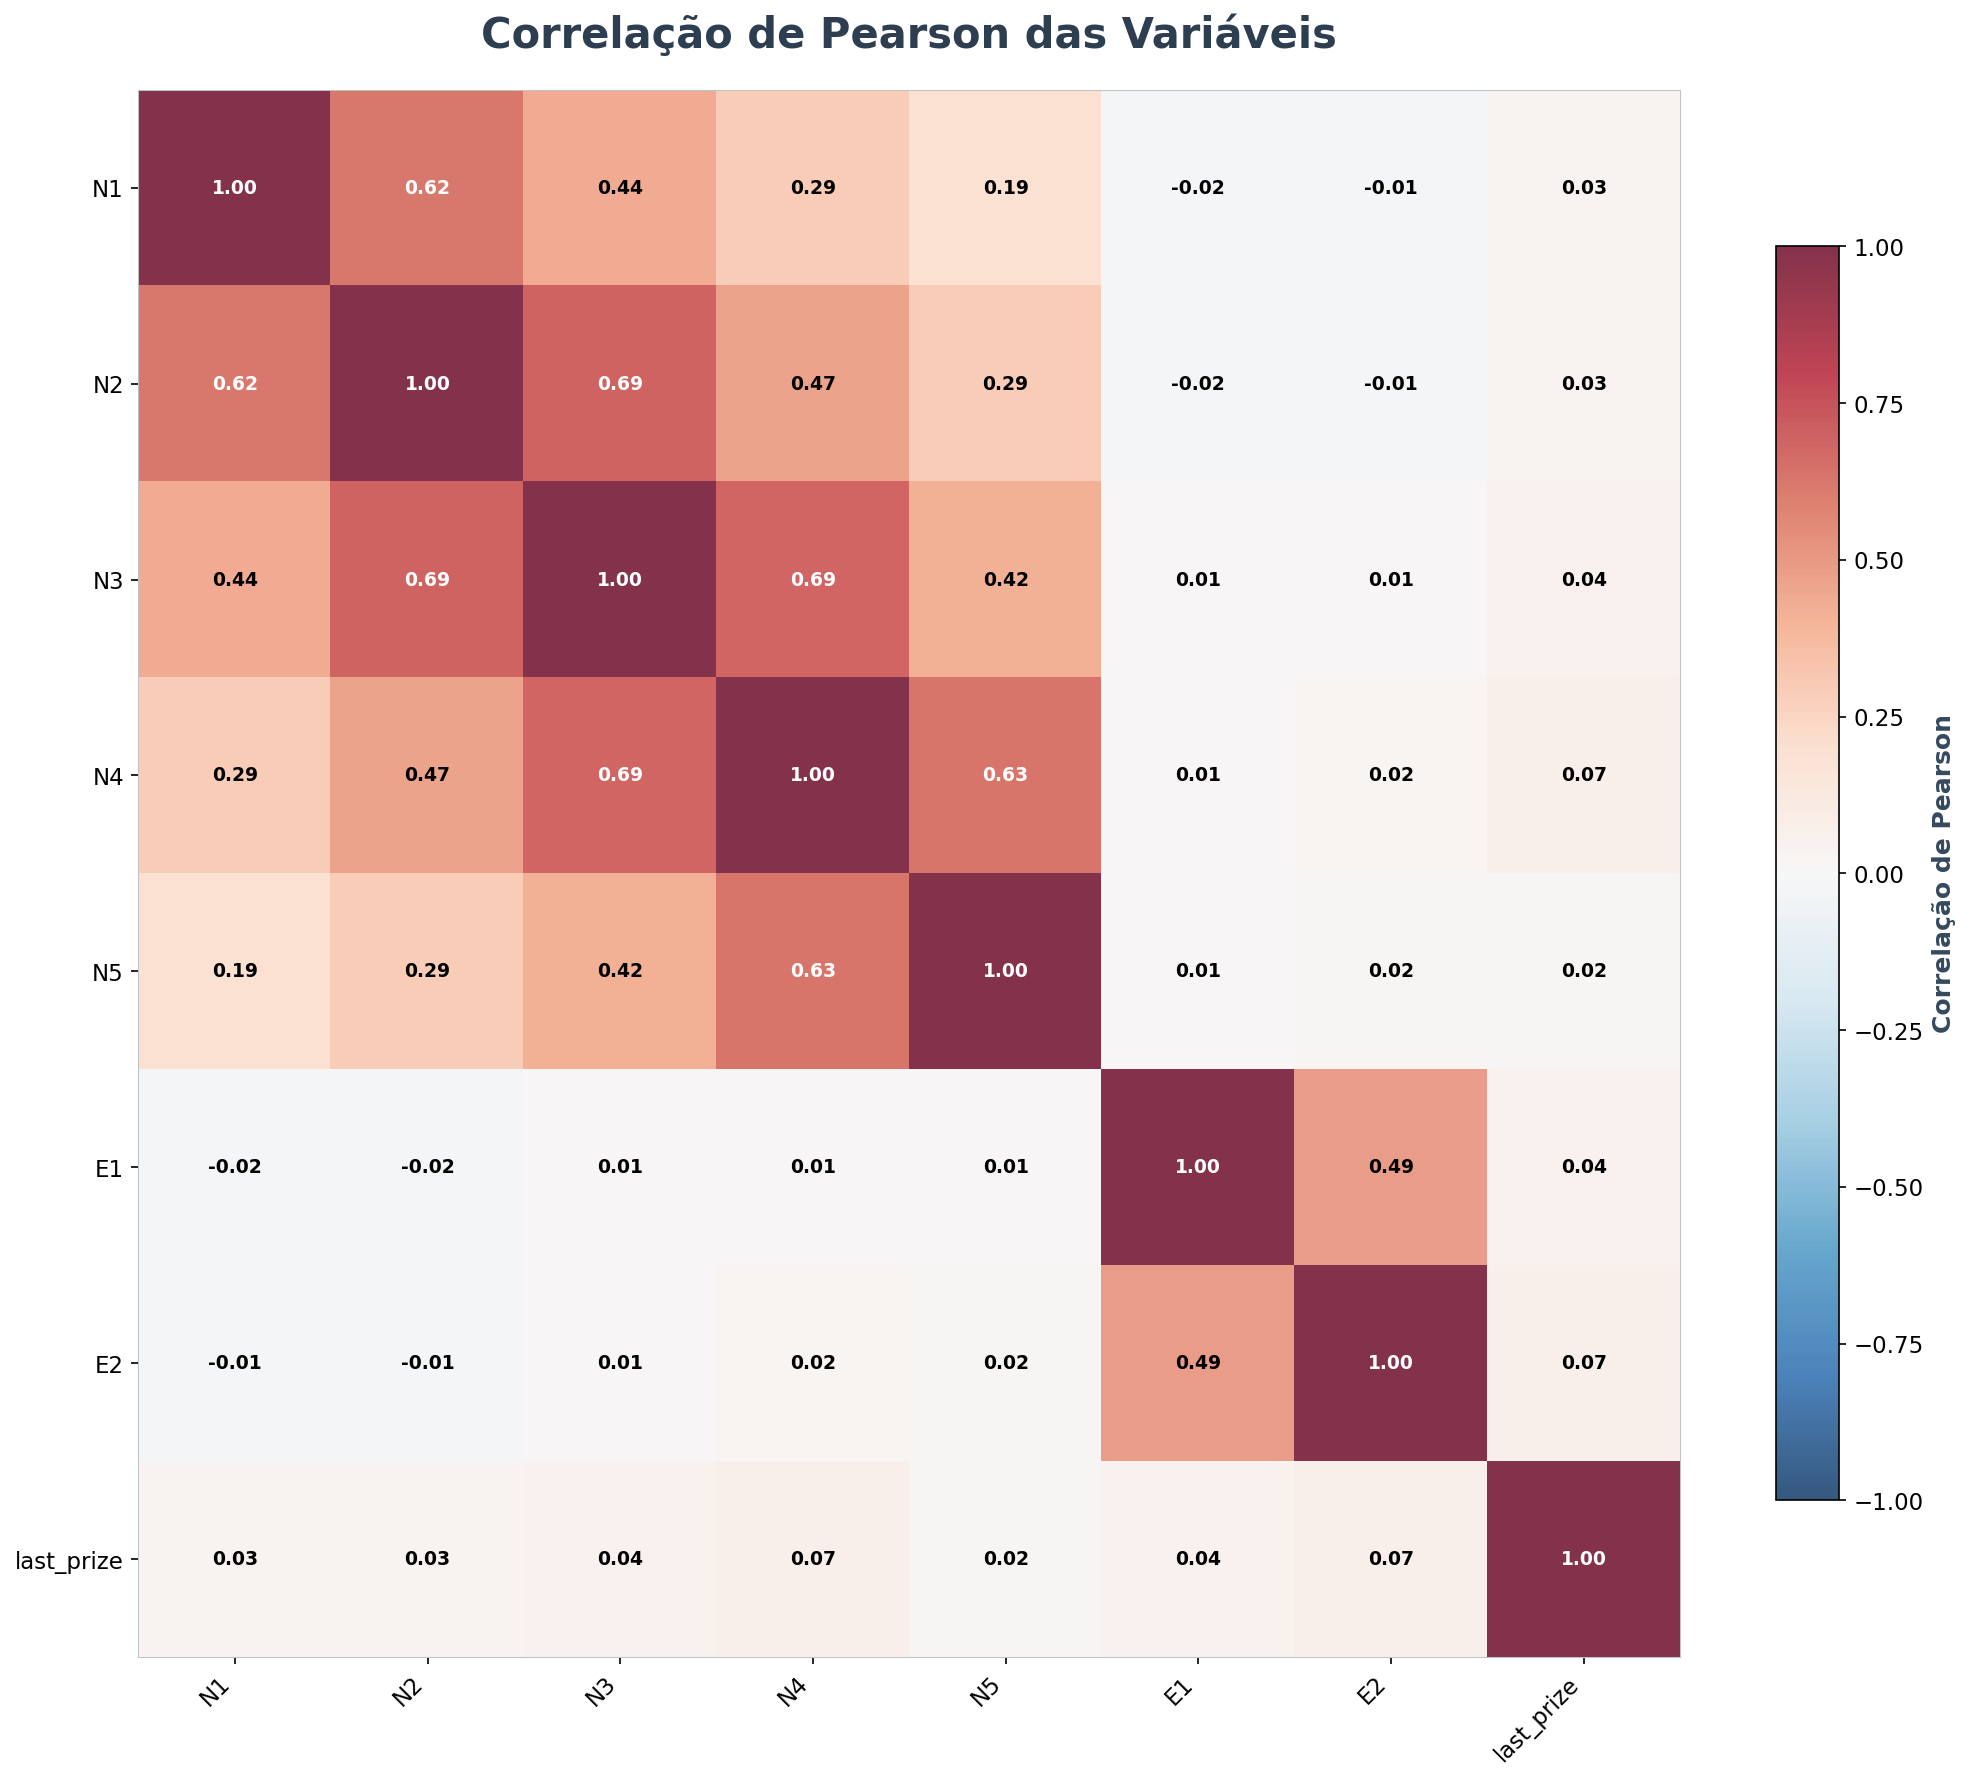

In [23]:
plot_pearson_correlation(df_corr, titulo='Correlação de Pearson das Variáveis')

### 2.6.2. V-Cramer

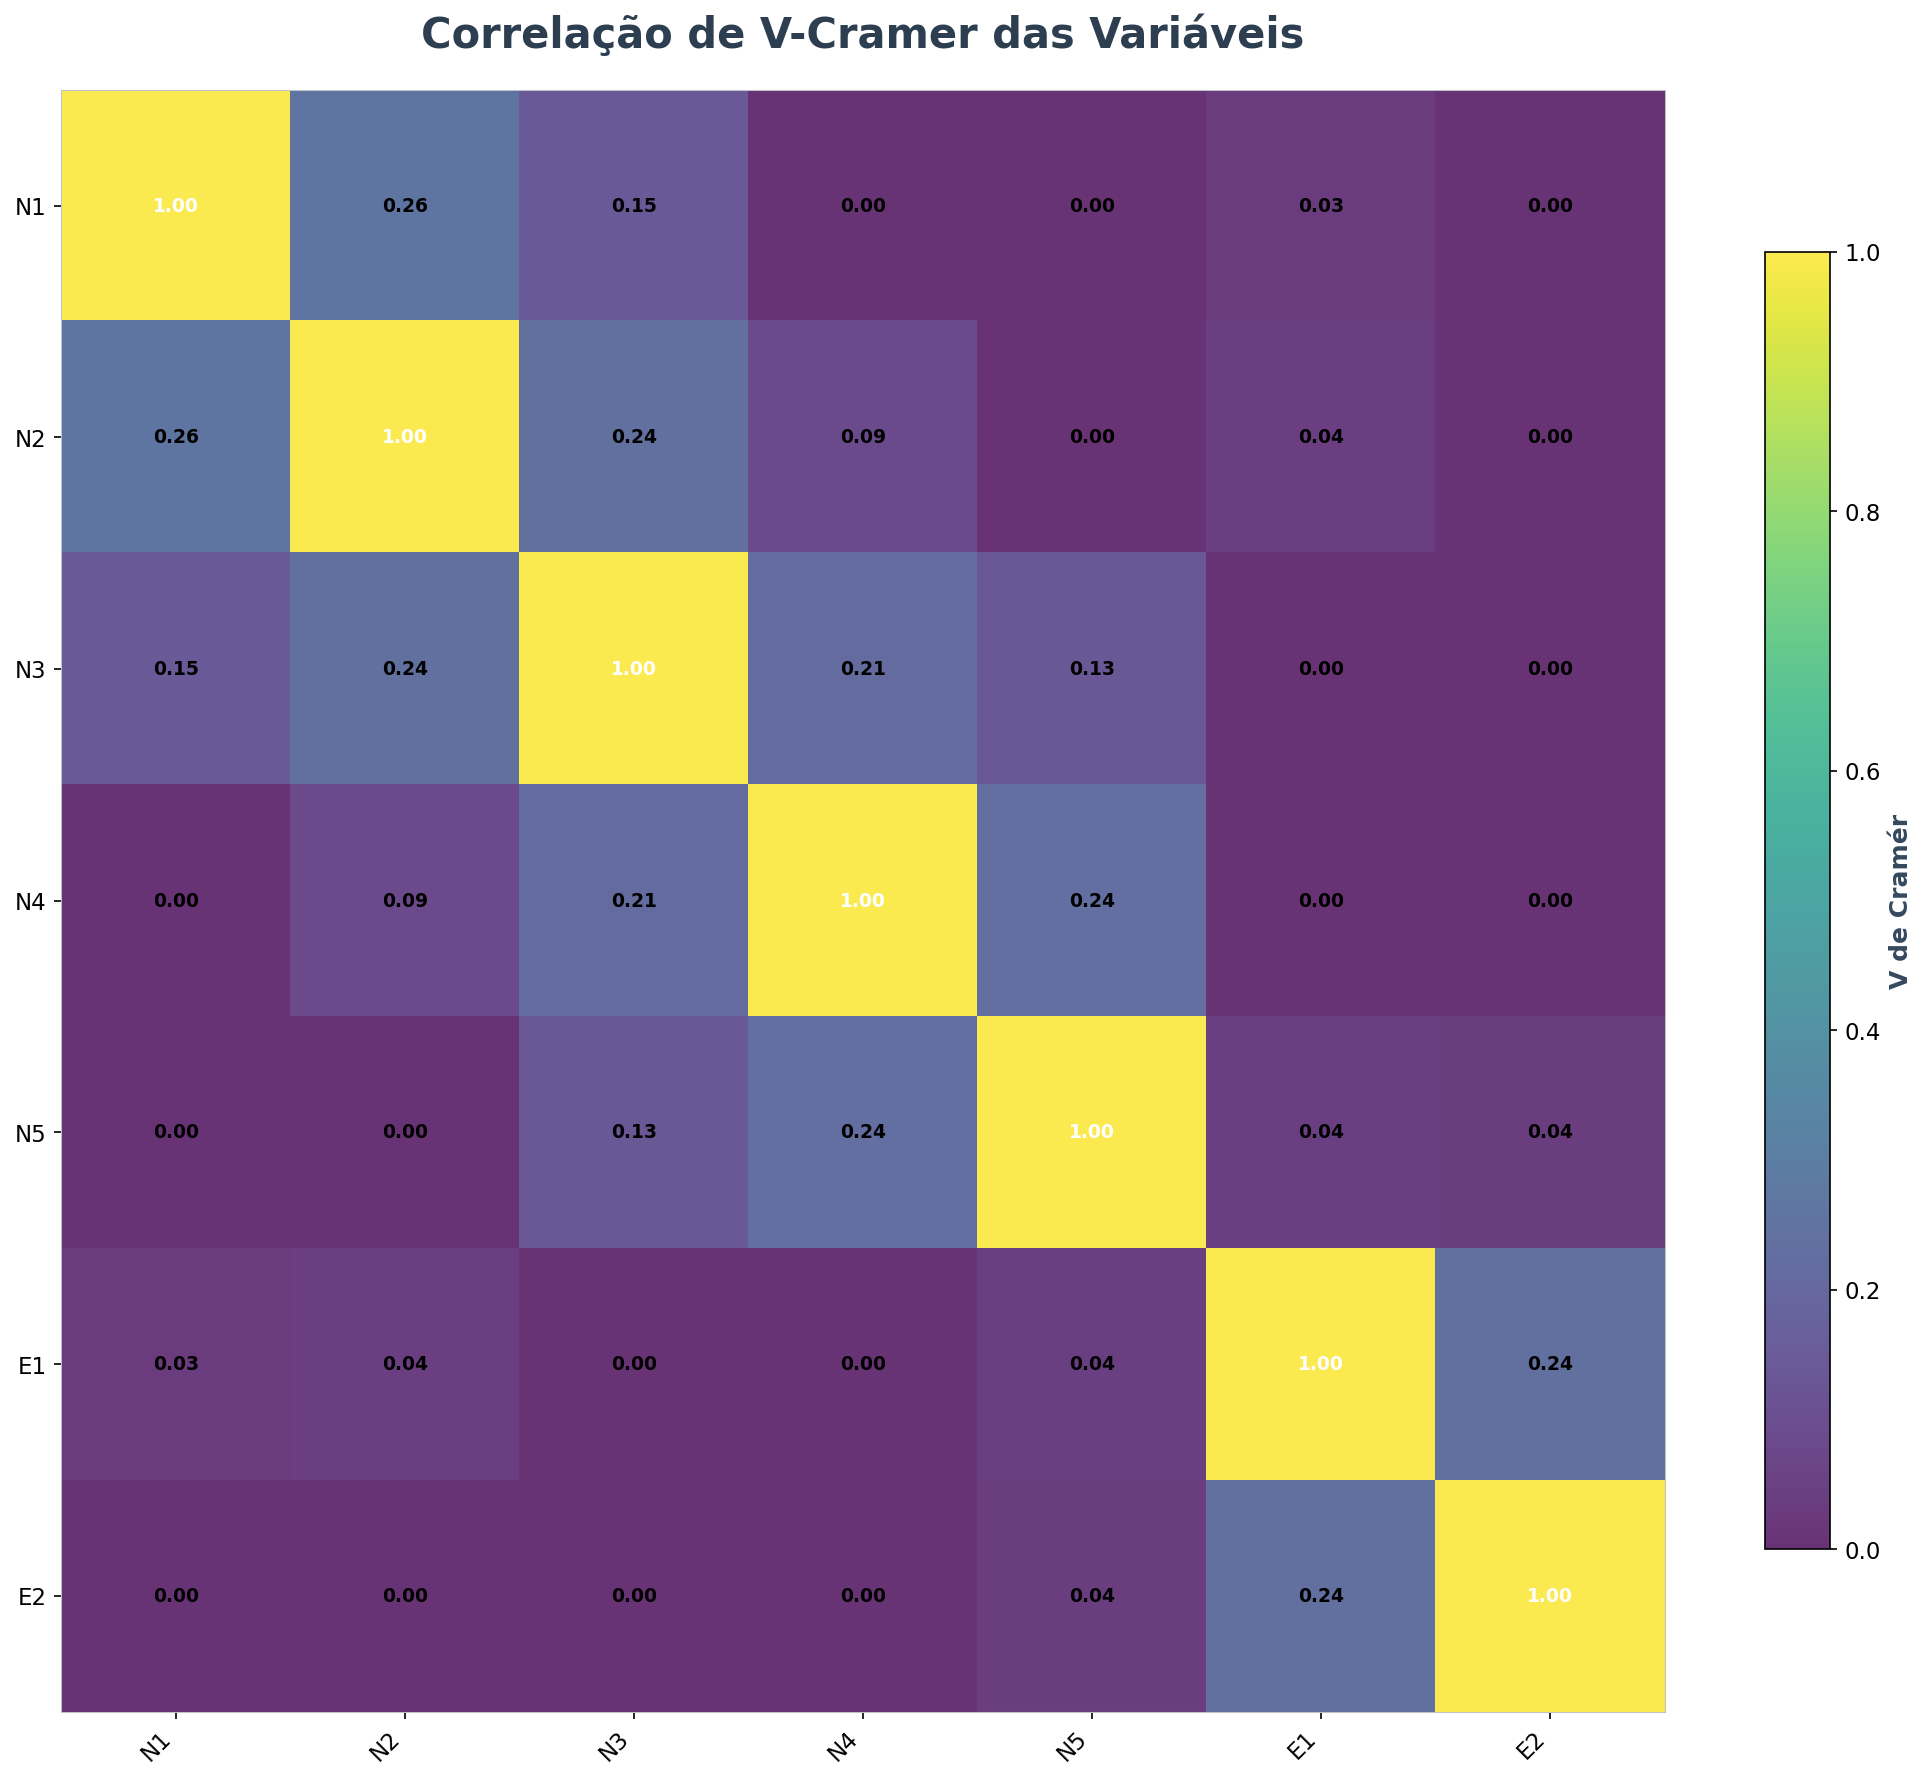

In [24]:
plot_cramer_correlation(df_corr, titulo='Correlação de V-Cramer das Variáveis')

## 2.6. Stats

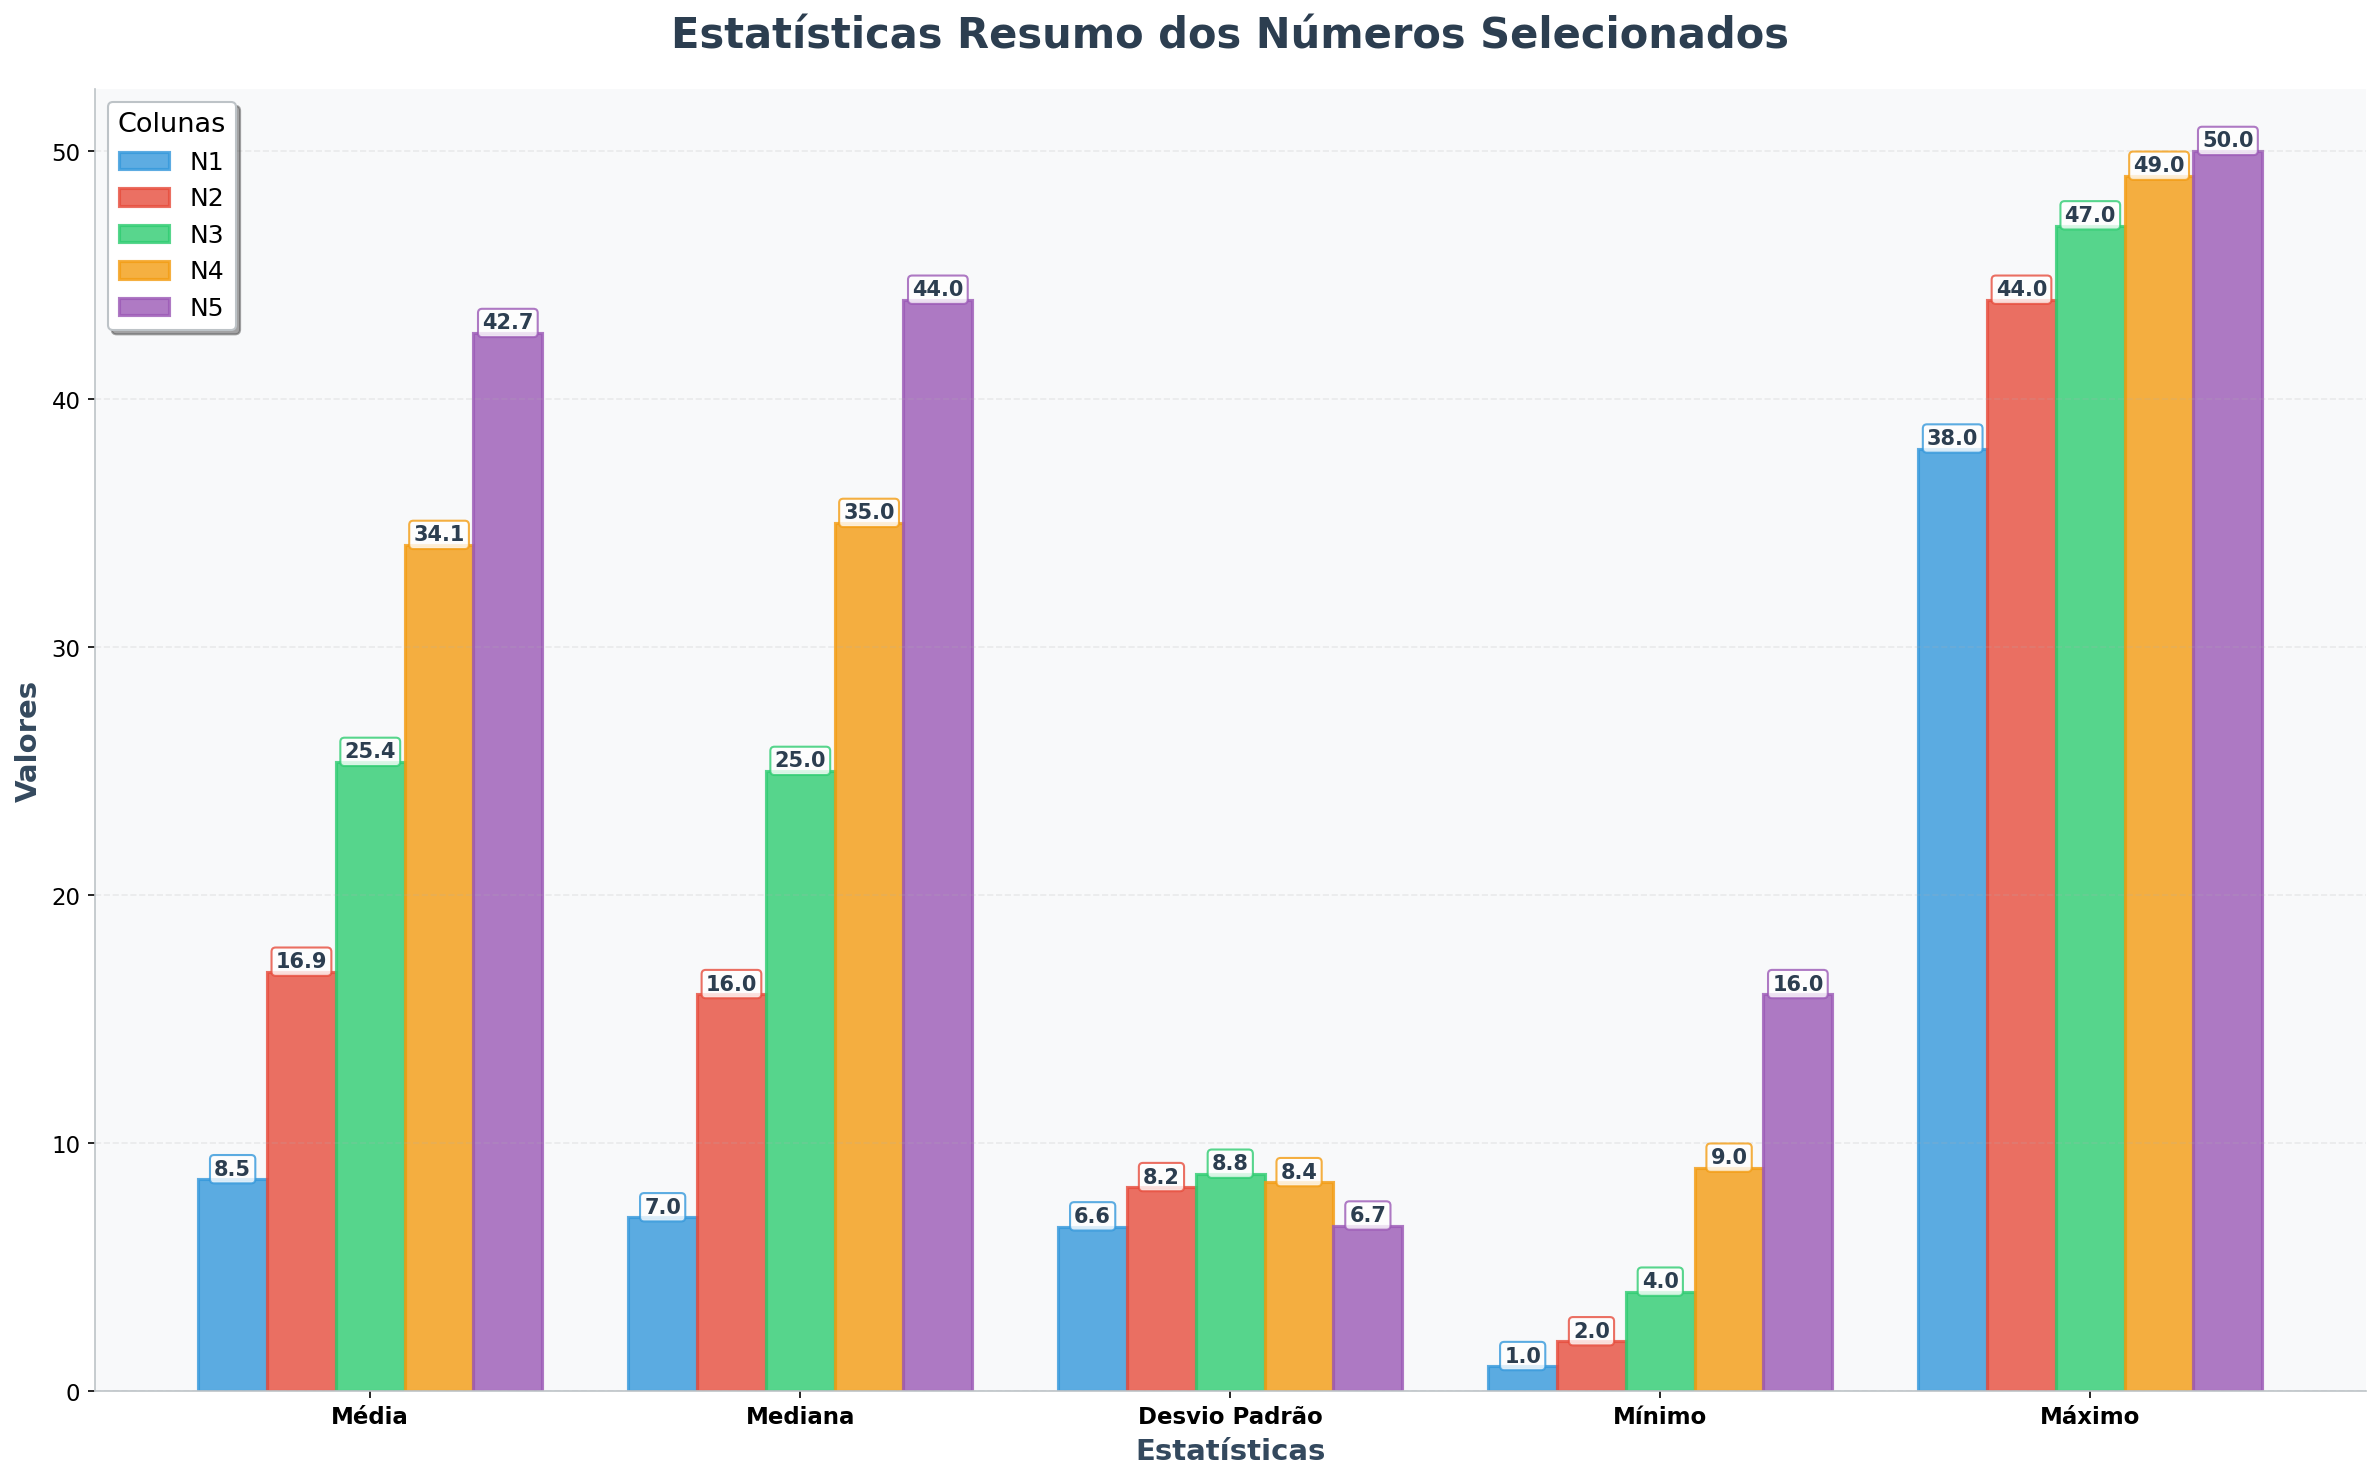

In [ ]:
plot_estatisticas_resumo(df, df_numeros.columns, titulo='Estatísticas Resumo dos Números Selecionados')

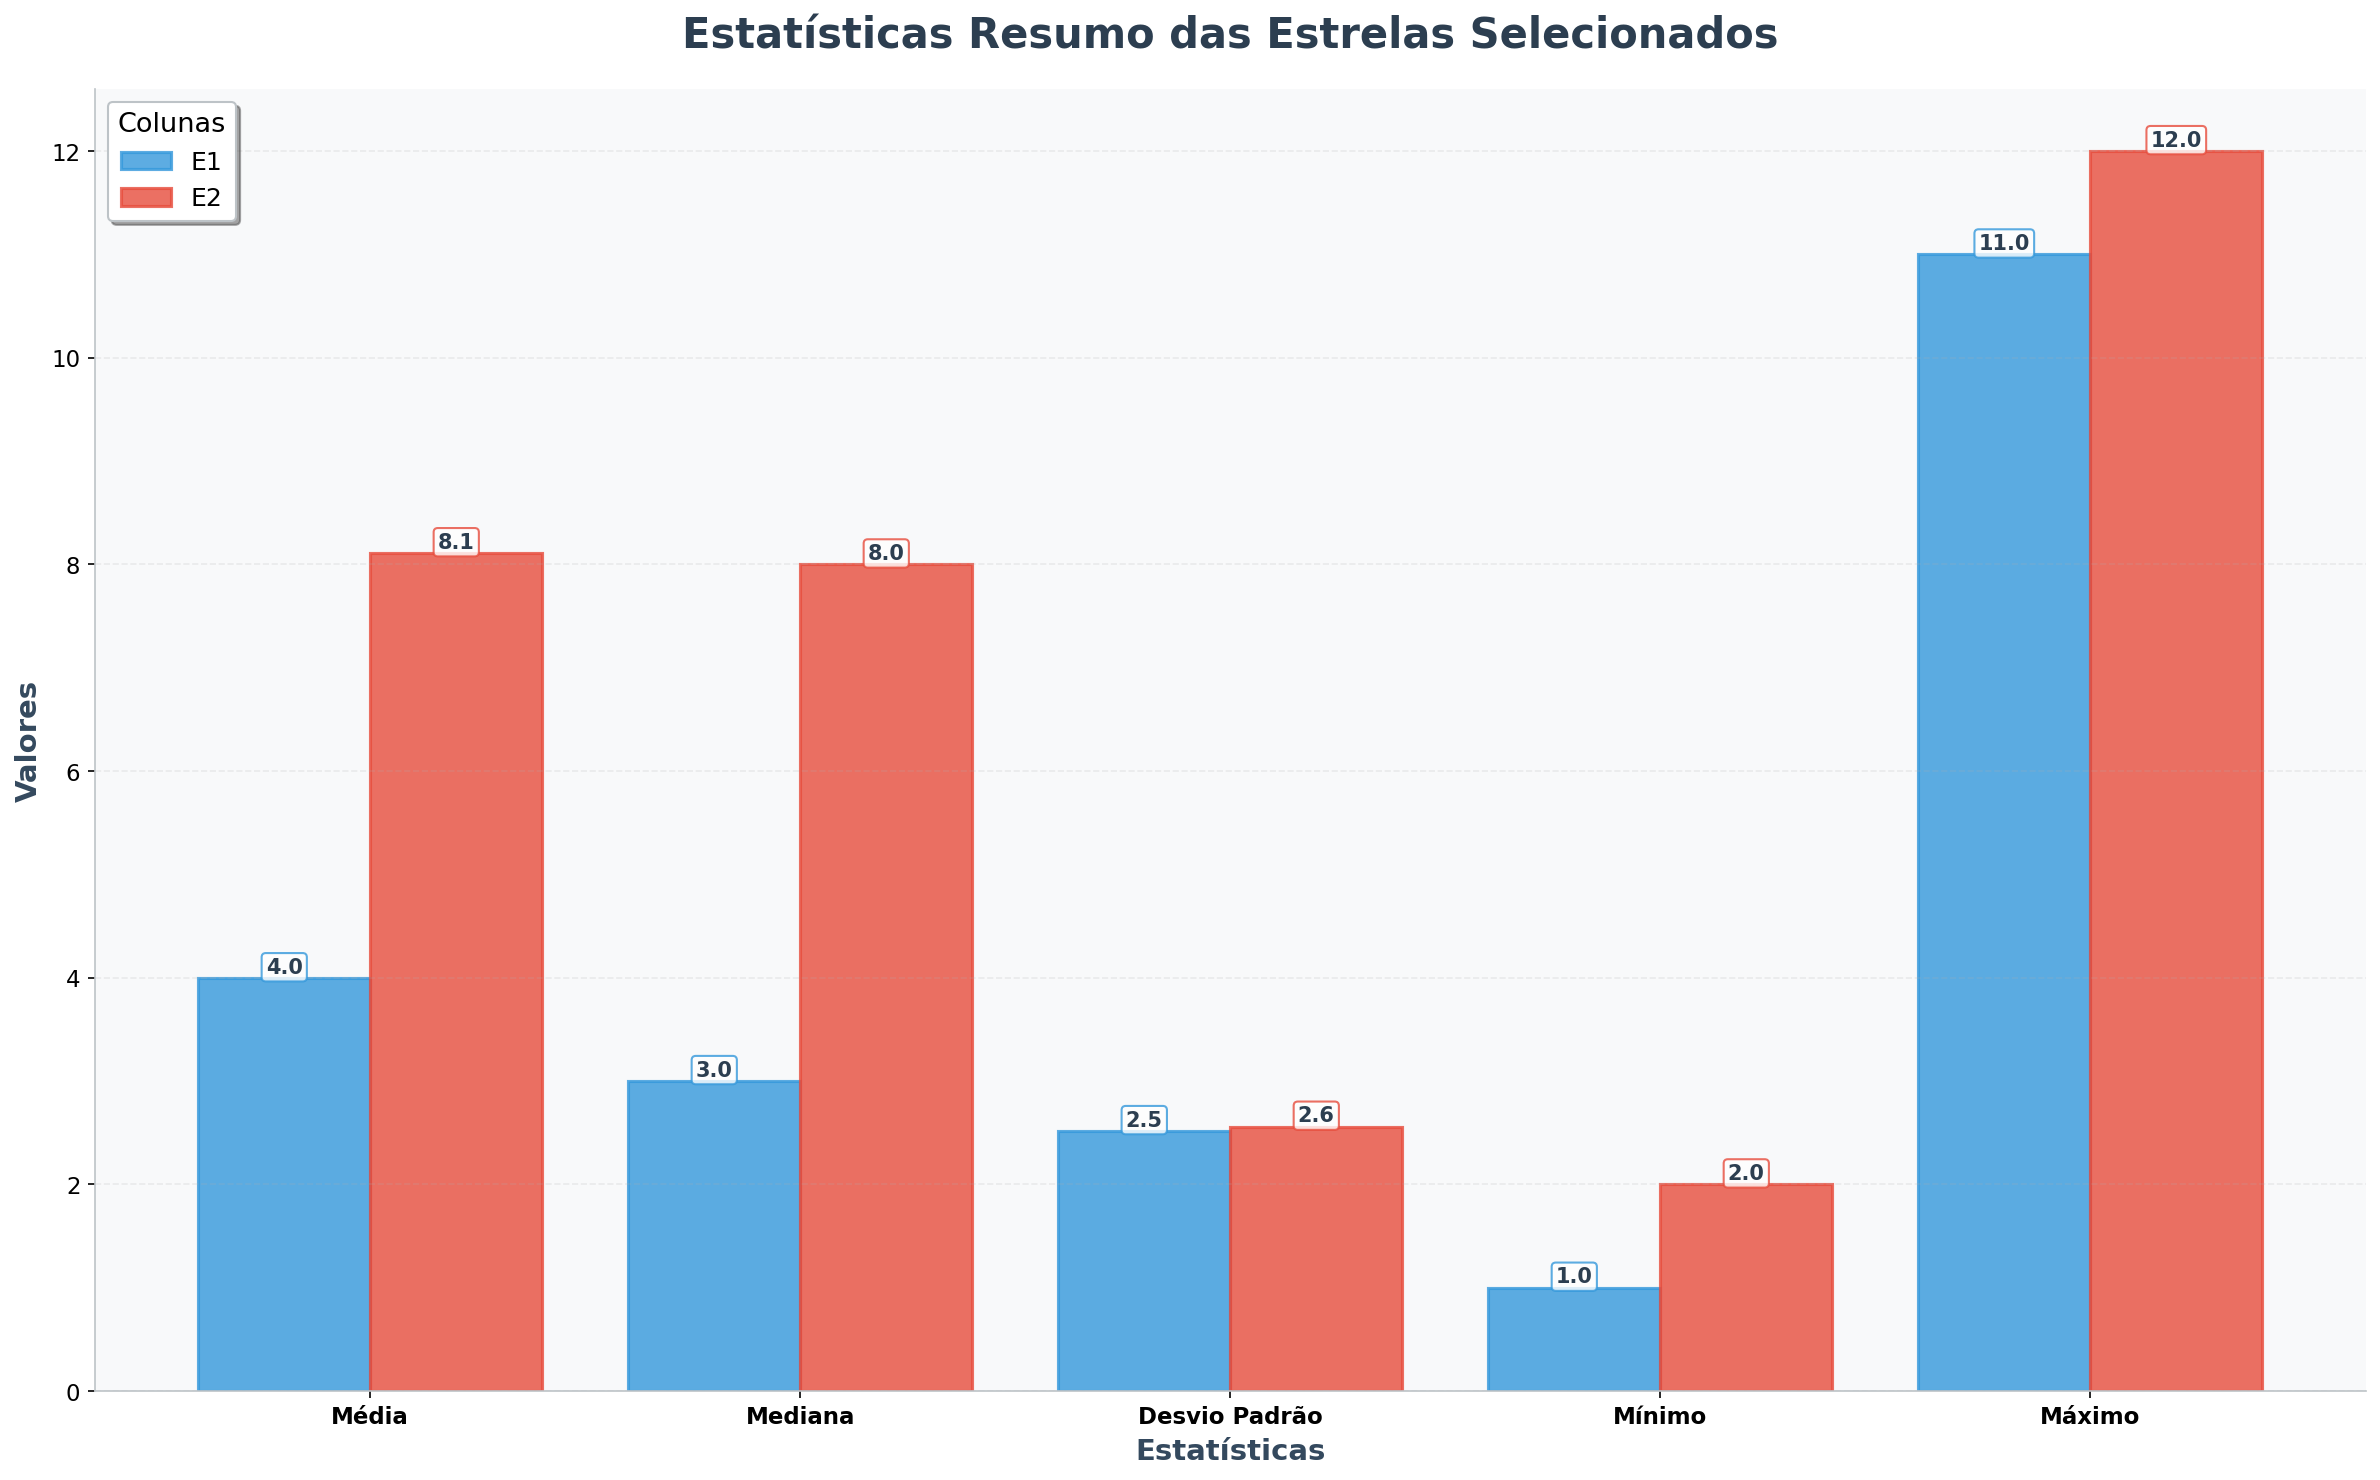

In [26]:
plot_estatisticas_resumo(df, df_estrelas.columns, titulo='Estatísticas Resumo das Estrelas Selecionados')